# Рекомендательная система музыкального сервиса

**Заказчик:** сервис Яндекс Музыка, популярный стриминговый сервис с большим каталогом - более 70 млн. треков.

**Проблема:** Взаимодействие с музыкальным сервисом должно быть удобным, простым и приятным. Для этого пользователю нужно предлагать треки или подборки, основываясь на его вкусах и предпочтениях. Это делают почти все популярные сервисы, — немногие пользователи захотят тратить время на поиски потенциально интересной музыки, единожды опробовав отточенную систему персональных рекомендаций. 

**Бизнес-задача:** Необходимо облегчить пользовательский опыт, создав систему персональных рекомендаций посредством машинного обучения.

**Дополнительно:** Создание MVP рекомендательной системы, fine-tuning моделей не требуется. Предоставлены данные по взаимодействиям ~1,4 млн пользователей с 1 млн треков. Определена дата разделения тренировочной и тестовой выборок - 16 декабря 2022 года, все взаимодействия раньше указанной даты использовать как тренировочную выборку.

# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [1]:
import os
import gc

import pandas as pd
import numpy as np
import s3fs
import joblib
import scipy 
from dotenv import load_dotenv
from plotly.subplots import make_subplots
from sklearn.preprocessing import LabelEncoder
from implicit.als import AlternatingLeastSquares
from threadpoolctl import threadpool_limits
from catboost import CatBoostClassifier, Pool
from sklearn.decomposition import TruncatedSVD
from collections import Counter

> Необходимо указать данные для подключения к хранилищу S3 в файле `.env` в следующем формате:

```sh
AWS_ENDPOINT_URL=https://storage.yandexcloud.net
AWS_REGION=ru-central1
AWS_S3_BUCKET=<BUCKET_NAME>
AWS_ACCESS_KEY_ID=<ACCESS_KEY>
AWS_SECRET_ACCESS_KEY=<SECRET_KEY>
```

In [2]:
# Определение констант
load_dotenv()

RANDOM_STATE = 42
PERCENTILES = [.01, .05, .25, .5, .75, .95, .99]

S3_BUCKET = os.getenv("AWS_S3_BUCKET")

STORAGE_OPTIONS={
    "endpoint_url": os.getenv("AWS_ENDPOINT_URL"), 
    "key": os.getenv("AWS_ACCESS_KEY_ID"), 
    "secret": os.getenv("AWS_SECRET_ACCESS_KEY"),
    "client_kwargs":{"region_name": os.getenv("AWS_REGION")},
    "config_kwargs": {"signature_version": "s3v4"}
}

# Дата для разбиения выборки на тренировочную и тестовую
SPLIT_DATE = pd.to_datetime("2022-12-16")

# Указать False для работы без S3, сохранение в текущем каталоге
S3 = True

In [3]:
# Настройка

# Фиксация SEED
np.random.seed(RANDOM_STATE)

# Настройки вывода pandas
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('plotting.backend', 'plotly')

# Увеличиваем частоту очистки памяти
gc.set_threshold(10, 3, 2)

In [ ]:
# Функцию сохранения данных перенес в раздел инициализации, так как она понадобится
# в 3 этапе, после перезапуска ядра для высвобождения ресурсов.
 
def save_data(df: pd.DataFrame, file_name: str, dir_name: str, index = False, 
              s3: bool = S3, bucket = S3_BUCKET, storage_options = STORAGE_OPTIONS):
    """
    Функция для сохранения датасета pandas по указанному имени файла `file_name` 
    в указанной директории `dir_name`. Параметр `s3` регулирует сохранение локально или 
    в хранилище S3 в директорию 'recsys' указанного `bucket` с применением `storage_options`.
    """
    if s3:
        df.to_parquet(
            f"s3://{bucket}/recsys/{dir_name}/{file_name}", 
            engine="pyarrow", index=index,
            storage_options=storage_options
        )
    else:
        df.to_parquet(f"../{dir_name}/{file_name}", index=True)

In [5]:
# Функция извлечение таргетов и новой тестовой выборки 
# также вынесена в раздел инициализации из построения признаков
# для возможности использования после перезапуска ядра
def split_target_test(df: pd.DataFrame, hot_user_ids: list):
    """
    Функция разбиения тестовой выборки на таргет и новый тест.

    Parameters
    ----------
    df : DataFrame
        Тестовая выборка для разбиения
    hot_user_ids : list
        Список id горячих пользователей

    Returns
    -------
    (target, test) : (DataFrame, Dataframe)
        Возвращает выборку для таргетов и новую тестовую выборку
    """
    # Ранжирование треков
    target_ids = df.groupby("user_id")["item_seq"].rank(
        method="dense", ascending=True)
    # Определение ранних треков
    target_ids = target_ids <= np.ceil(
        df.groupby("user_id")["item_id"].transform("count") / 2)
    # Получение горячих пользователей
    target_ids = (
        target_ids &
        df.reset_index().merge(
            pd.DataFrame({"user_id": hot_user_ids, "hot": True}),
            how="left", on="user_id"
        ).set_index("index")["hot"].notna()
    )
    return df[target_ids], df[~target_ids]

# === ЭТАП 1 ===

## Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

Файлы расположены в директории `initial-data`, в случае их отсутствия файлы скачиваются с хранилища Яндекс.

In [6]:
try:
    tracks = pd.read_parquet("initial-data/tracks.parquet")
    catalog_names = pd.read_parquet("initial-data/catalog_names.parquet")
    interactions = pd.read_parquet("initial-data/interactions.parquet")
except FileNotFoundError:
    tracks = pd.read_parquet("https://storage.yandexcloud.net/mle-data/ym/tracks.parquet")
    catalog_names = pd.read_parquet("https://storage.yandexcloud.net/mle-data/ym/catalog_names.parquet")
    interactions = pd.read_parquet("https://storage.yandexcloud.net/mle-data/ym/interactions.parquet")

In [7]:
tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   albums    1000000 non-null  object
 2   artists   1000000 non-null  object
 3   genres    1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB


В файле tracks.parquet расположены данные о треках:
- track_id — идентификатор музыкального трека;
- albums — список идентификаторов альбомов, содержащих трек;
- artists — список идентификаторов исполнителей трека;
- genres — список идентификаторов жанров, к которым принадлежит трек.

In [8]:
catalog_names.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   type    object
 2   name    object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB


В файле catalog_names.parquet располагаются сведения об именах артистов, названия альбомов, треков и жанров:
- id — идентификатор одной из каталожных единиц (трека, альбома, исполнителя, жанра);
- type — тип идентификатора;
- name — имя (название) каталожной единицы.

In [9]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


В файле interactions.parquet данные о том, какие пользователи прослушали тот или иной трек:
- user_id — идентификатор пользователя,
- track_id — идентификатор музыкального трека,
- track_seq — номер места трека в истории пользователя,
- started_at — дата начала прослушивания трека.

Файл содержит более 222 млн. записей и занимает 5.4 Gb памяти.

## Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [10]:
tracks

,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 2490809, 6007655, 17294156]",[84],[11]
...,...,...,...,...
999995,101478482,[21399811],[5540395],"[3, 75]"
999996,101490148,[21403052],[9078726],"[11, 20]"
999997,101493057,[21403883],[11865715],"[44, 75]"
999998,101495927,[21404975],[4462686],"[3, 75]"


Сведения по альбомам, артистам и жанрам представлены в виде списка для каждого трека. Оценим на наличие явных дубликатов.

In [11]:
print(
    "Количество дубликатов id трека:",
    tracks.duplicated(subset=["track_id"]).sum()
)

Количество дубликатов id трека: 0


Дубликаты треков отсутствуют. Оценим распределение количества альбомов, артистов и жанров по каждому треку.

In [12]:
tracks_info = pd.DataFrame()

for col in ["albums", "artists", "genres"]:
    tracks_info[col] = tracks.explode(col)\
        .groupby("track_id")[col].count().describe(
            percentiles=PERCENTILES)

tracks_info.T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
albums,1000000.00,3.13,29.72,0.00,1.00,1.00,1.00,1.00,2.00,6.00,24.00,2844.00
artists,1000000.00,1.26,0.68,0.00,0.00,1.00,1.00,1.00,1.00,3.00,4.00,26.00
genres,1000000.00,1.65,0.57,0.00,1.00,1.00,1.00,2.00,2.00,2.00,3.00,10.00


Основная масса треков входят в 1-2 альбома, однако имеется не менее 5% треков, которые входят в более 6 альбомов, а для 1% треков количество альбомов составляет от 24 до 2844. По артистам основная масса треков не превышает одного, при этом имеются треки до 26 артистов. По жанрам распределение чаще всего от 1 до 2-х жанров, максимальное количество до 10. Имеются пропуски по всем полям.

Для дальнейшей анализа предварительно оценим содержимое датасета `catalog_names`.

In [13]:
catalog_names.sample(15, random_state=RANDOM_STATE)

,id,type,name
1514369,51822590,track,Музыка в фильмах Тарантино
437151,8810199,album,Shadow
1800488,95436616,track,Ключ
635810,19044912,album,Gnomi Di Natale
1436508,43503873,track,Пароль
1736619,79526639,track,"The Center Will Not Hold, Twenty Centuries of Stony Sleep"
977652,4299219,track,Мегасити
1502417,50616059,track,Hotdamn!
1648149,66726337,track,Carita de Inocente
717816,1628267,artist,Nick Urb


Датасет содержит различные типы наименований, оценим количество уникальных id по каждому типу.

In [14]:
catalog_names["type"].value_counts()

type
track     1000000
album      658724
artist     153581
genre         166
Name: count, dtype: int64

Количество имен треков в датасете `catalog_names` аналогично количеству записей в датасете `tracks`. Взглянем как распределяются идентификаторы по каждому типу.

In [15]:
catalog_names.groupby(by="type")["id"].agg(["min", "median", "mean", "max"])

,min,median,mean,max
type,,,,
album,3,5557071.50,7020933.38,21461648
artist,4,3297272.00,3927042.01,16102782
genre,0,82.50,206.23,1542
track,26,34550465.50,36851209.38,101521819


Значения id разных типов данных превышают их количество в датасете, причем нумерация начинается с довольно малых значений. Возможно это ограничения выгруженного датасета, а полный датасет по всем трекам, альбомам, артистам и жанрам содержит больше значений. Либо присвоение идентификаторов имеет не инкрементный характер или преобразовано из других значений в числовые. В целом все идентификаторы сдвинуты к более низким значениям, о чем говорит более высокие значения средней относительно медианы.

Для проверки соответствия имен треков, объединим датасеты по track_id.

### Имена треков

In [16]:
# Добавление наименований треков
tracks = tracks.merge(
    catalog_names.query("type == 'track'")[["id", "name"]], 
    how="left", left_on="track_id", right_on="id",
).drop(columns="id").rename(
    columns={"name": "track_name"}
)
print(
    "Количество пропусков по именам треков:",
    tracks["track_name"].isna().sum()
)

Количество пропусков по именам треков: 0


Все наименования треков представлены в датасете. Оценим соответствие по альбомам.

### Альбомы

In [17]:
# Разнесение списка альбомов в строки датафрейма
tracks = tracks.explode("albums").rename(columns={"albums": "album"})

print(
    "Уникальных id альбомов:", 
    tracks['album'].nunique()
)

Уникальных id альбомов: 658724


Количество уникальных id альбомов совпадает с количеством альбомов в датасете `catalog_names`. Оценим наличие пропусков и дубликатов.

In [18]:
print(
    "Дубликатов по альбомам:",
    tracks.duplicated(subset=["track_id", "album"]).sum()
)
print(
    "Пропусков по альбомам",
    tracks["album"].isna().sum()
)

Дубликатов по альбомам: 0
Пропусков по альбомам 18


Дубликаты по альбомам отсутствуют, однако имеется небольшое количество пропусков. Взглянем на треки с пропущенными альбомами.

In [19]:
tracks.query("album.isna()")

,track_id,album,artists,genres,track_name
310821,20200372,NaN,[],[],На скотч
310826,20200380,NaN,[],[],Yo Te Quiero (Я тебя люблю)
312469,20305116,NaN,[],[],Мой путь
312474,20305121,NaN,[],[],Вечность
320353,20756854,NaN,[],[],Виновата
326588,21196099,NaN,[],[],Are You with Me
326592,21196103,NaN,[],[],Historia de Amor
326594,21196105,NaN,[],[],Stronger Than Ever
326596,21196107,NaN,[],[],Here We Go
326598,21196109,NaN,[],[],Long Story Short


Можно заметить, что для данных треков пропуски не только по имени альбома, а также по артисту и жанру - списки пустые. Встречаются русские и казахские наименования треков, а также наименования на латиннице. Судя по названиям, среди них могут быть достаточно популярные песни, однако это непонятно в виду отсутствия сведений по артистам. Стоит обратить внимание на данный факт, возможно имеются какие то проблемы с данными, как в процессе выгрузки, так и на самом сервисе. Проверим соответствие id и наименований альбомов в датасетах.

In [20]:
# Добавление наименований альбомов
tracks = tracks.merge(
    catalog_names.query("type == 'album'")[["id", "name"]], 
    how="left", left_on="album", right_on="id",
).drop(columns="id").rename(
    columns={"name": "album_name"}
)
tracks[["album","album_name"]].isna().sum()

album         18
album_name    18
dtype: int64

По альбомам пропуски отсутствуют, за исключением тех треков, для которых отсутствуют сведения об альбомах. Соответственно все id альбомов присутствуют в датасете `catalog_names`. Взглянем на треки, входящие в наибольшее количество альбомов.

In [21]:
tracks.groupby(
    by=["track_id", "track_name"]
)["album"].count().rename("album_count").sort_values(ascending=False).head(20).reset_index()

,track_id,track_name,album_count
0,23233264,Liquid,2844
1,24642198,One by One,2843
2,23233263,Drifting,2837
3,24269035,Out of the Blue 2015,2827
4,24006507,Lamentation,2824
5,24006508,For Keeps,2820
6,23843412,Black Orpheus,2817
7,24178049,Vault,2817
8,23227138,Wave,2809
9,24178050,Start Tonight,2807


Судя по всему, датасет содержит также альбомы, которые являются сборниками треков. Взглянем на альбомы, содержащие наибольшее количество треков.

In [22]:
tracks.groupby(
    by=["album", "album_name"]
)["track_id"].count().rename("track_count").sort_values(ascending=False).head(20).reset_index()

,album,album_name,track_count
0,7293229,Daily Easy English Expression Podcast,1001
1,6271311,«Подкаст Лайфхакера»,880
2,7121797,"Виват, история!",368
3,6966125,Брендятина,348
4,6316997,Newочём,334
5,16272876,24 Hours Of R&B,289
6,9091882,ТЕД на русском,282
7,6408431,The Big Beard Theory,260
8,4060253,Коллекция,246
9,496501,Integrale,244


В альбомы, которые имеют наибольшее количество треков входят подкасты, сборники музыкальных треков и аудиоверсии мультфильмов. Например, часто встречается наименование "Летние хиты", содержащее довольно близкое количество треков.

### Артисты

In [23]:
# Разнесение списка артистов в строки датафрейма
tracks = tracks.explode("artists").rename(columns={"artists": "artist"})

print(
    "Уникальных id артистов:", 
    tracks['artist'].nunique()
)

Уникальных id артистов: 153581


Количество уникальных id артистов совпадает с количеством артистов в датасете `catalog_names`. Оценим на наличие пропусков и дубликатов

In [24]:
print(
    "Дубликатов по артистам:",
    tracks.duplicated(subset=["track_id", "album", "artist"]).sum()
)
print(
    "Пропусков по артистам:",
    tracks[tracks["artist"].isna()].drop_duplicates(subset=["track_id"]).shape[0]
)

Дубликатов по артистам: 0
Пропусков по артистам: 15369


Имеется значительно большее количество пропусков по артистам - более 15 тысяч.

In [25]:
# Добавление имен артистов
tracks = tracks.merge(
    catalog_names.query("type == 'artist'")[["id", "name"]], 
    how="left", left_on="artist", right_on="id",
).drop(columns="id").rename(
    columns={"name": "artist_name"}
)

In [26]:
tracks[
    tracks["artist"].isna() | tracks["artist_name"].isna()
].drop_duplicates(subset=["track_id"])[["artist", "artist_name"]].isna().sum().rename(index="count")

artist         15369
artist_name    15369
Name: count, dtype: int64

Пропуски по имени артиста приходится также только на пропущенные записи. Заполнение пропусков по артистам можно попробовать с использованием альбомов, так как часто альбомы относятся к одному артисту, отдельные песни из которого возможно имеют пропуски по артисту. Для начала сгруппируем артистов по альбомам и оценим полученные данные.

In [27]:
print("Альбомов в зависимости от количества артистов:")
tracks.groupby(by=["album"])["artist"].count().value_counts() \
    .to_frame().rename(columns={"count": "albums"}).head(20).T

Альбомов в зависимости от количества артистов:


artist,1,2,3,4,5,6,7,8,10,9,11,12,13,14,15,16,17,18,19,20
albums,265769,126716,53931,32907,19901,17322,11786,11084,9539,9479,8172,8128,6203,5352,4367,4099,3380,3263,3081,3030


На основную массу альбомов приходится 1-6 артистов. Получим наиболее часто встречающихся артистов по каждому альбому.

In [28]:
# Получение списка альбомов с указанием количества артистов в нем 
# и id наиболее часто встречающихся артистов

albums = tracks.groupby(by=["album"])["artist"].agg(
    func=["count", pd.Series.mode]
).rename(columns={"count": "artist_count", "mode": "artist"})
albums

,artist_count,artist
album,,
3,2,16
12,8,84
13,7,90
17,2,183
26,1,2785081
...,...,...
21458141,1,215458
21458207,1,1720
21458968,2,"[1227, 1106295]"


Встречаются записи, в которых присутствует более одного наиболее часто встречающегося артиста на альбом в виде списка. Оценим такие записи.

In [29]:
albums[albums["artist"].apply(lambda x: x.dtype == object)].sort_values(by="artist_count")

,artist_count,artist
album,,
19031257,0,[]
19073300,0,[]
2289397,0,[]
2289404,0,[]
19184949,0,[]
...,...,...
3102005,197,"[9170, 83668]"
73493,199,"[4781, 118895]"
16632681,202,"[4594680, 4622988]"


Для более 180 тысяч альбомов невозможно определить одного артиста, при этом встречаются альбомы, в которых полностью отсутствуют артисты.

In [30]:
print(
    "Количество альбомов без артистов:",
    albums.query("artist_count == 0")["artist"].count()
)

Количество альбомов без артистов: 1265


Оценим какие треки входят в альбомы, для которых не указаны артисты.

In [31]:
no_artist = albums.query("artist_count == 0").index.to_list()
tracks.query("album.isin(@no_artist)")[["track_id", "track_name", "artist"]].drop_duplicates()

,track_id,track_name,artist
757231,3599591,Cry For Love,NaN
1056846,10063296,Теплое Солнце,NaN
1098077,12122918,17 & 4,NaN
1464611,20210042,Fear of the dark,NaN
1464613,20210069,La Grange,NaN
...,...,...,...
4016372,101201589,Троя | История на ночь #40,NaN
4016384,101219571,Главное — не победа!,NaN
4016417,101243616,Кинокраши. В каких актеров и актрис мы были влюблены (и почему это вообще происходит),NaN
4016443,101292599,"«Все у женщины в психике настроено для любви, даже тело». Профилактируем отрастание яиц. Ксукса, Маша и мудроженственность",NaN


Треков в альбомах без артиста не превышает 15 тысяч, это практически все треки, артисты в которых не указаны. Оценим по каким трекам пропущены артисты, но в альбоме они имеются по другим трекам.

In [32]:
have_artists = albums.query("artist_count > 0").index.to_list()
print(
    "Количество треков, в альбомах которых есть артисты:",
    tracks.query("artist.isna()").query("album.isin(@have_artists)")["track_id"].nunique()
)

Количество треков, в альбомах которых есть артисты: 745


Довольно малое количество пропусков артистов приходится на альбомы с имеющимися данными по артистам. Оценим на какие треки имеются альбомы с 1 артистом.

In [33]:
have_artists = albums.query("0 < artist_count < 2").index.to_list()
tracks.query("artist.isna()").drop(columns="genres").drop_duplicates() \
    .query("album.isin(@have_artists)").merge(
        albums.reset_index(), on="album", suffixes=("", "_album")
    )

,track_id,album,artist,track_name,album_name,artist_name,artist_count,artist_album
0,47015090,6315201,NaN,БС6: Максим Дорофеев: Как подружиться с внутренней обезьянкой?,Будет сделано!,NaN,1,171
1,47015091,6315201,NaN,БС39: Василий Ключарёв: Как понять своё поведение с помощью науки?,Будет сделано!,NaN,1,171
2,47015095,6315201,NaN,БС7: Николай Додонов: Как управлять привычками?,Будет сделано!,NaN,1,171
3,47015099,6315201,NaN,БС17: Олег Брагинский: Как стать гением эффективности?,Будет сделано!,NaN,1,171
4,48684781,6315201,NaN,"БС108: Никита Маклахов: Эй, полегче! Итоги 2018 и планы на 2019",Будет сделано!,NaN,1,171
...,...,...,...,...,...,...,...,...
176,74424184,6316697,NaN,«Я смогла зарабатывать иллюстрацией» Ия Гаас и умение ценить свою работу,Это непросто,NaN,1,171
177,47276186,6318898,NaN,14. Спецвыпуск. Как влияет медитация на продуктивность?,Продуктивный Роман,NaN,1,171
178,50057373,6318898,NaN,Анонс,Продуктивный Роман,NaN,1,171
179,76191574,6318898,NaN,109. Как общаться в мессенджерах продуктивно,Продуктивный Роман,NaN,1,171


Всего 181 трек без артиста имеет альбом с одним артистом. Причем это в основном артист с id 171, который представлен в разных альбомах. Также по имени трека в альбоме "Будет сделано!" можно определить, что имеются разные артисты, так как их имена указаны в названии трека. Оценим по какому треку указан артист с id 171 из альбома "Будет сделано!".

In [34]:
tracks.query("artist == 171 and album == 6315201")

,track_id,album,artist,genres,track_name,album_name,artist_name
3235348,47015098,6315201,171,"[62, 72, 77]",БС81: Никита Маклахов: Как проводить уходящий год?,Будет сделано!,сборник


Имя артиста с id 171 - "сборник", хотя в имени трека указан Никита Маклахов. Судя по всему id данного артиста указывается в треках для сборников произведений, где присутствует множество артистов. Взглянем на наиболее часто встречающихся артистов в треках. 

In [35]:
tracks.drop_duplicates(subset=["track_id", "artist"]) \
    .groupby(by=["artist", "artist_name"])["track_id"].count() \
    .rename("track_count").sort_values(ascending=False) \
    .reset_index(level=1).head(15)

,artist_name,track_count
artist,,
118708,Владимир Высоцкий,2038
171,сборник,1378
139896,Armin van Buuren,1273
9170,Wolfgang Amadeus Mozart,1221
1227,Johann Sebastian Bach,1130
11818,Hans Zimmer,1058
1551,Pyotr Ilyich Tchaikovsky,1043
3989,Frank Sinatra,1021
10987,Elvis Presley,975


Больше всего треков в сервисе приходится на артиста "Владимир Высоцкий" - более 2000, возможно это не только музыкальные треки его исполнения, но также и другие произведения (стихи, проза). Вторым артистом по количеству треков является "сборник" с id 171. Далее по мере уменьшения количества треков идут в основном достаточно известные композиторы и исполнители песен.

Судя по большому количеству треков без артистов, данный факт достаточно распространен - возможно для части треков артисты отсутствуют и это нормально для датасета. Большого смысла заполнять пропущенных артистов для треков, где в альбомах имеются артисты не вижу.

### Жанры

In [36]:
# Разнесение списков жанров в строки датафрейма
tracks = tracks.explode("genres").rename(columns={"genres": "genre"})

print(
    "Уникальных id жанров:", 
    tracks['genre'].nunique()
)

Уникальных id жанров: 173


Уникальных id жанров в датасете `tracks` - 173, что больше количества жанров в датасете `catalog_names` - 166. Оценим наличие пропусков и явных дубликатов.

In [37]:
print(
    "Дубликатов по жанрам:",
    tracks.duplicated(subset=["track_id", "album", "artist", "genre"]).sum()
)
print(
    "Пропусков по жанрам:",
    tracks[tracks["genre"].isna()].drop_duplicates(subset=["track_id"]).shape[0]
)

Дубликатов по жанрам: 0
Пропусков по жанрам: 3687


Дубликаты по жанрам также отсутствуют, однако имеются менее 4 тысяч треков без указания жанра. Объединим датасеты по id жанров для проверки их соответствия.

In [38]:
# Добавление наименований жанров
tracks = tracks.merge(
    catalog_names.query("type == 'genre'")[["id", "name"]], 
    how="left", left_on="genre", right_on="id",
).drop(columns="id").rename(
    columns={"name": "genre_name"}
)

In [39]:
# вывод сведений по отсутствующим жанрам
tracks[
    tracks["genre"].isna() | tracks["genre_name"].isna()
].drop_duplicates(subset=["track_id"])[["genre", "genre_name"]].isna().sum().rename(index="count")

genre          3687
genre_name    52032
Name: count, dtype: int64

В датасете `tracks` имеется довольно большое количество записей с id жанров, которые отсутствуют в датасете `catalog_names`. Оценим количество уникальных значений для таких записей.

In [40]:
print(
    "Количество неизвестных id жанров:",
    tracks[tracks["genre_name"].isna()]["genre"].nunique()
)

Количество неизвестных id жанров: 30


Можно отметить достаточно большое количество жанров - 30 штук, id которых имеется в датасете `tracks`, но они отсутствуют в датасете `catalog_names`. Соответственно в датасете `catalog_names` также имеются id жанров, которые не представлены в датасете `tracks`. Оценим такие id жанров.

In [41]:
# Получение пересекающихся id по двум датасетам
genres_int = tracks[~tracks["genre_name"].isna()]["genre"].unique().tolist()
genres_tracks = tracks[~tracks["genre"].isin(genres_int)]["genre"].dropna().sort_values().unique().tolist()
print("id жанров из датасета tracks:")
print(genres_tracks)
print(f"Всего {len(genres_tracks)} жанров.\n")
genres_catalog = catalog_names.query("type == 'genre'").apply(
    lambda x: x["id"] if x["id"] not in genres_int else None, 
    axis=1
).dropna().astype(int).to_list()
print("id жанров из датасета catalog_names:")
print(genres_catalog)
print(f"Всего {len(genres_catalog)} жанров.")

id жанров из датасета tracks:
[124, 126, 130, 131, 132, 133, 134, 135, 146, 148, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169]
Всего 30 жанров.

id жанров из датасета catalog_names:
[0, 34, 36, 42, 46, 96, 100, 103, 119, 218, 310, 345, 405, 540, 597, 657, 794, 819, 907, 1058, 1080, 1101, 1370]
Всего 23 жанров.


Каких-либо очевидных возможных ошибок по id жанра определить не получается. Возможно проблема в неполном датасете `catalog_names`, или ошибки в датасете `tracks`, либо имеют место проблемы с выгрузкой данных. Оценим жанры из датасета `catalog_names`.

In [42]:
catalog_names.query("type == 'genre' and id.isin(@genres_catalog)")

,id,type,name
812305,0,genre,all
812339,34,genre,caribbean
812341,36,genre,classic
812347,42,genre,holiday
812351,46,genre,latin
812401,96,genre,other
812405,100,genre,rockmusic
812408,103,genre,audiolibrary
812424,119,genre,poprock
812433,218,genre,fusion


Можно отметить, что к отсутствующим в датасете `tracks` жанрам относятся довольно распространенные жанры, такие как classic, rockmusic, poprock и т.п. Возможно это дублирующиеся наименования, которые не используются в сервисе. Также встречается немалое количество региональных жанров, а также неопределенные жанры - `all`, `other`.

In [43]:
# удаление переменных
del tracks_info, albums, no_artist, have_artists, genres_catalog, genres_int, genres_tracks, catalog_names

### Заполнение пропусков

Пропуски по альбомам и артистам заполним заглушкой `unknown`, в части жанров пропуски заполним жанром 96 - `other`, который отсутствует в датасете и будет использоваться в качестве заглушки. Сведения по артистам и альбомам применяться для обучения модели не будут, а только для оценки треков. А в части жанров желательно согласовать такую заглушку с заказчиком, возможно для таких целей лучше использовать другой жанр, например, 0 - `all`. Все заглушки, кроме жанров не будут использоваться для обучения моделей, а только для визуальной оценки треков.

In [44]:
na_values = {
    "album_name": "unknown", "artist_name": "unknown", 
    "genre": 96, "genre_name": "other"
}
tracks = tracks.fillna(na_values)
print("Количество пропусков:")
display(tracks[na_values.keys()].isna().sum())
del na_values

Количество пропусков:


album_name     0
artist_name    0
genre          0
genre_name     0
dtype: int64

### Взаимодействия

In [45]:
interactions.describe(percentiles=PERCENTILES).T

,count,mean,min,1%,5%,25%,50%,75%,95%,99%,max,std
user_id,222629898.00,687576.66,0.00,13803.00,69002.00,343371.00,687973.00,1031127.00,1305939.00,1361008.00,1374582.00,396903.29
track_id,222629898.00,36536224.96,26.00,21259.00,170252.00,14808489.00,35524737.00,56511373.00,83371057.00,94296022.00,101521819.00,26617816.84
track_seq,222629898.00,462.14,1.00,2.00,9.00,56.00,181.00,506.00,1837.00,4213.00,16637.00,825.73
started_at,222629898,2022-08-29 16:39:44.541336320,2022-01-01 00:00:00,2022-01-30 00:00:00,2022-03-19 00:00:00,2022-07-02 00:00:00,2022-09-15 00:00:00,2022-11-09 00:00:00,2022-12-18 00:00:00,2022-12-27 00:00:00,2022-12-31 00:00:00,NaN


В датасете представленны данные за 2022 год. Проверим наличие явных дубликатов и пропущенных значений.

In [46]:
print(
    "Количество дубликатов:",
    # Проверка наличия дубликатов по нумерации треков для пользователей
    interactions.duplicated(subset=["user_id", "track_seq"]).sum()
)

Количество дубликатов: 0


In [47]:
print("Количество пропусков:")
print(interactions.isna().sum())

Количество пропусков:
user_id       0
track_id      0
track_seq     0
started_at    0
dtype: int64


Дубликаты и пропуски отсутствуют, оценим количество уникальных значений признаков.

In [48]:
print("Количество уникальных значений:")
interactions.nunique()

Количество уникальных значений:


user_id       1373221
track_id      1000000
track_seq       16637
started_at        365
dtype: int64

В датасете имеется более 1.37 миллиона уникальных пользователей, а количество треков аналогичное как в датасете `tracks`. Если поле `track_sec` идет по нарастающей для каждого пользователя, то максимальное количество прослушанных треков на пользователя - более 16.5 тысяч, что соответствует максимальному значению данного поля. Количество уникальных дат - 365, что соответствует количеству дней в невисокосном 2022 году. Проверим, имеются ли записи о повторных прослушиваниях одного и того же трека.

In [49]:
print(
    "Количество дубликатов треков по пользователям:",
    interactions.duplicated(subset=["user_id", "track_id"]).sum()
)

Количество дубликатов треков по пользователям: 0


Датасет не содержит сведений о повторном прослушивании треков. Проверим нет ли пропусков в значении `track_sec` сравнив максимальное значение с общим количеством треков на пользователя.

In [50]:

print(
    "Количество пльзователей с пропущенными треками:",
    interactions.groupby(by="user_id")[["track_id", "track_seq"]].agg(
        func={"track_id": "count", "track_seq": "max"}
    ).loc[lambda x: x["track_id"] != x["track_seq"]].shape[0]
)

Количество пльзователей с пропущенными треками: 0


Пропуски в нумерации треков у пользователей отсутствуют. Оценим соответствие id треков датасетов путем добавления всех треков датасета `interactions` и количества взаимодействий пользователей к датасету `tracks`.

In [51]:
print(
    "Количество треков, которые отсутствуют во взаимодействиях:",
    tracks.merge(
        interactions.groupby(by="track_id")["user_id"].count() \
            .rename(index="users").reset_index(),
        how="outer"
    )["users"].isna().sum()
)

Количество треков, которые отсутствуют во взаимодействиях: 0


Все треки датасета `track` представлены в датасете `interactions`. Вероятнее всего в датасете содержатся только треки, по которым были новые взаимодействия пользователей за рассматриваемый период. Оценим индексацию пользователей.

In [52]:
print("Индексы пользователей:")
print(pd.Series(interactions["user_id"].unique()))

Индексы пользователей:
0                0
1                1
2                2
3                3
4                4
            ...   
1373216    1374578
1373217    1374579
1373218    1374580
1373219    1374581
1373220    1374582
Length: 1373221, dtype: int32


Индексы пользователей начинаются с 0 и в целом увеличиваются инкрементно, однако по значениям последних индексов можно отметить наличие пропусков, так как эти значения превышают количество записей более чем на 1.3 тысячи. Вероятнее всего не все пользователи прослушивали треки в имеющийся период, либо прослушивали только треки, по которым было менее 5 новых взаимодействий.

Оценим количество прослушанных пользователями треков.

In [53]:
user_tracks = interactions.groupby("user_id")["track_id"].count() \
    .rename("Треков на пользователя:")
user_tracks.describe(percentiles=PERCENTILES).to_frame().T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Треков на пользователя:,1373221.00,162.12,351.28,1.00,11.00,12.00,23.00,55.00,154.00,650.00,1576.00,16637.00


По количеству прослушанных пользователями треков значения начинаются с 1, а для основной массы пользователей имеется не более 1600 взаимодействий. Присутствуют пользователи, поведение которых сильно отличается от основной массы с количеством прослушиваний вплоть до 16637. Возможно это какие-нибудь боты, либо пользователи для тестирования. Также это могут быть пользователи, которые беспорядочно слушают все треки, однако по таким пользователям не совсем понятно как определять их предпочтения, желательно таких клиентов исключить из выборки, либо сегментировать таких пользователей и проводить обучение двух моделей на разных датасетах - одну на основной массе пользователей, а другую на пользователях с большим количеством взаимодействий. Вопрос об исключению таких пользователей лучше предварительно урегулировать с Заказчиком.

Оценим какое влияние может оказать на датасет исключение пользователей при различных порогах по максимальному количеству прослушиваний: 
- 1.5 межквартильных размаха от 3 квартиля $Q3 + 1.5*IQR$;
- 3 межквартильных размаха от 3 квартиля $Q3 + 3*IQR$;
- 95-й перцентиль (входит в 2 сигма при нормальном распределении);
- 99-й перцентиль;
- 99.7 перцентиль (входит в 3 сигма при нормальном распределении);
- 99.85% перцентиль (включает половину от предыдущего остатка).

In [54]:
print(f"Всего пользователей: {user_tracks.shape[0]:,.0f}")
print(f"Всего взаимодействий: {interactions.shape[0]:,.0f}")

# Получение списка ограничений
user_tholds = []
for q in [25, 75, 95, 99, 99.7, 99.85]:
    user_tholds.append(int(np.percentile(user_tracks, q=q)))

# Вычисление порогов по межквартильному интервалу
iqr = user_tholds[1] - user_tholds[0]
user_tholds[0] = int(1.5 * iqr + user_tholds[1])
user_tholds[1] = int(3 * iqr + user_tholds[1])

for q in user_tholds:
    print()
    print(f"Порог взаимодействий для пользователей: {q}")
    # Получение списка пользователей на удаление
    delete_users = user_tracks.loc[lambda x: x > q]
    print(
        f"Пользователей на удаление: {delete_users.shape[0]:,.0f} ({delete_users.shape[0]/user_tracks.shape[0]:.2%})")
    delete_idx = interactions["user_id"].isin(delete_users.index.to_list())
    print(
        f"Взаимодействий к удалению: {delete_idx.sum():,.0f} ({delete_idx.mean():.2%})")

del q, iqr

Всего пользователей: 1,373,221
Всего взаимодействий: 222,629,898

Порог взаимодействий для пользователей: 350
Пользователей на удаление: 154,853 (11.28%)
Взаимодействий к удалению: 129,028,291 (57.96%)

Порог взаимодействий для пользователей: 547
Пользователей на удаление: 88,055 (6.41%)
Взаимодействий к удалению: 99,921,680 (44.88%)

Порог взаимодействий для пользователей: 650
Пользователей на удаление: 68,632 (5.00%)
Взаимодействий к удалению: 88,345,082 (39.68%)

Порог взаимодействий для пользователей: 1576
Пользователей на удаление: 13,723 (1.00%)
Взаимодействий к удалению: 35,804,118 (16.08%)

Порог взаимодействий для пользователей: 2652
Пользователей на удаление: 4,117 (0.30%)
Взаимодействий к удалению: 16,747,259 (7.52%)

Порог взаимодействий для пользователей: 3482
Пользователей на удаление: 2,060 (0.15%)
Взаимодействий к удалению: 10,572,151 (4.75%)


Так как пользователи имеют наибольшее количество взаимодействий, их удаление окажет довольно значительное влияние на датасет - если использовать 1.5 межквартильного размаха, то удалению подлежит ~58% всех взаимодействий, по мере повышения порога только при значении в 99.85% (0.15% пользователей) приводит к удалению менее 5% от всего датасета. 

Возможно влияние на модель шума от таких пользователей с очень большим количеством прослушиваний треков по сравнению с основной массой пользователей. По пользователям, которые входят в 0.15% пользователей с самым большим количеством прослушиваний оставим только последние 10% треков, чтобы сохранить больше событий для модели.

In [55]:
# Получение всех id пользователей по событиям
delete_idx = interactions[["user_id", "track_seq"]].copy()
# Добавление количества прослушиваний по всем трекам 
# для возможности дальнейшей оценки треков на удаление
delete_idx["pop"] = interactions.groupby("track_id")["user_id"] \
    .transform("count").astype("int32")
# Добавление признака превышения порога по количеству треков
delete_idx = delete_idx.merge(
    right=(user_tracks.rename("delete") > user_tholds[5]).reset_index(), 
    on="user_id")
# Добавление порога по количеству треков у пользователя
delete_idx = delete_idx.merge(
    right=delete_idx.groupby("user_id")["track_seq"].quantile(q=0.9) \
        .rename("thold").astype("int32").reset_index(),
    on="user_id")
# Получение треков пользователей на удаление
delete_idx["delete"] = (delete_idx["track_seq"] < delete_idx["thold"]) & delete_idx["delete"]
# Возвращаем индексацию, которая изменилась при merge
delete_idx.index = interactions.index
print(f"Количество треков на удаление: {delete_idx['delete'].sum():,.0f} ({delete_idx['delete'].mean():.2%})")
print(f"Распределение популярности треков на удаление:")
delete_idx[delete_idx["delete"]]["pop"].describe(PERCENTILES) \
    .rename("Популярность:").to_frame().T

Количество треков на удаление: 9,512,155 (4.27%)
Распределение популярности треков на удаление:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Популярность:,9512155.00,3868.93,8579.74,5.00,7.00,20.00,203.00,865.00,3342.00,18798.00,43800.00,111062.00


При сохранении 10% взаимодействий удалению подлежат порядка 4.27% событий. Основная масса треков имеет небольшое количество прослушиваний, однако встречаются треки с очень большим количеством прослушиваний. Очистим датасет от избыточных событий.

In [56]:
# Удаление пользователй
interactions = interactions[~delete_idx["delete"]].copy()
print(f"Взаимодействий после удаления: {interactions.shape[0]:,.0f}")

Взаимодействий после удаления: 213,117,743


## Выводы

Приведём выводы по первому знакомству с данными:

1. Наличие проблем с данными:
    - для 18 треков не указаны сведения ни по альбомам, ни по артистам, ни по жанрам;
    - для более 15 тысяч треков отсутствуют сведения по артистам;
    - для чуть мене чем 3.7 тысячи треков отсутствуют сведения по жанрам;
    - имеется несоответствие жанров в датасетах `tracks` и `catalog_names` - 30 жанров отсутствуют в датасете `catalog_names`, однако имеется 23 жанра, которые не встречаются в датасете `tracks`. Предполагается, что допущена ошибка при выгрузке датасета `catalog_names`;
    - идентификаторы пользователей и треков имеют пропуски;
    - выявлено наличие пользователей, которые имеют очень большое количество взаимодействий с треками, которое сильно выбивается от основной массы пользователей.

Вероятнее всего сведения по артистам, жанрам и альбомам заполнены не для всех треков. Так как система рекомендаций будет возвращать только id треков в качестве рекомендаций, дополнительные сведения будут использованы только для дополнительного визуального контроля.

2. Корректирующие действия:
    - пропуски в наименовании альбомов и артистов были заполнены строкой `unknown`, наименования будут использованы только для визуальной оценки треков в рамках настоящего проекта, для рекомендационной системы они не нужны;
    - пропуски в жанрах были заменены отсутствующим в датасете с треками жанром `96` - `other`;
    - события по пользователям, у которых их общее количество превышает 99,85% всех пользователей сокращено до 10% самых последних.

В части пропусков в нумерации идентификаторов пользователей и треков - они будут закодированы посредством LabelEncoder для использования в разреженной матрице для ALS.

По пользователям, которые выбиваются от общей массы по количеству взаимодействий - данный вопрос необходимо выдвинуть на рассмотрение Заказчика, возможно стоит рассмотреть сегментацию пользователей и выдавать рекомендации для разных сегментов разными моделями.

# === ЭТАП 2 ===

## EDA

### Распределение количества прослушанных треков.

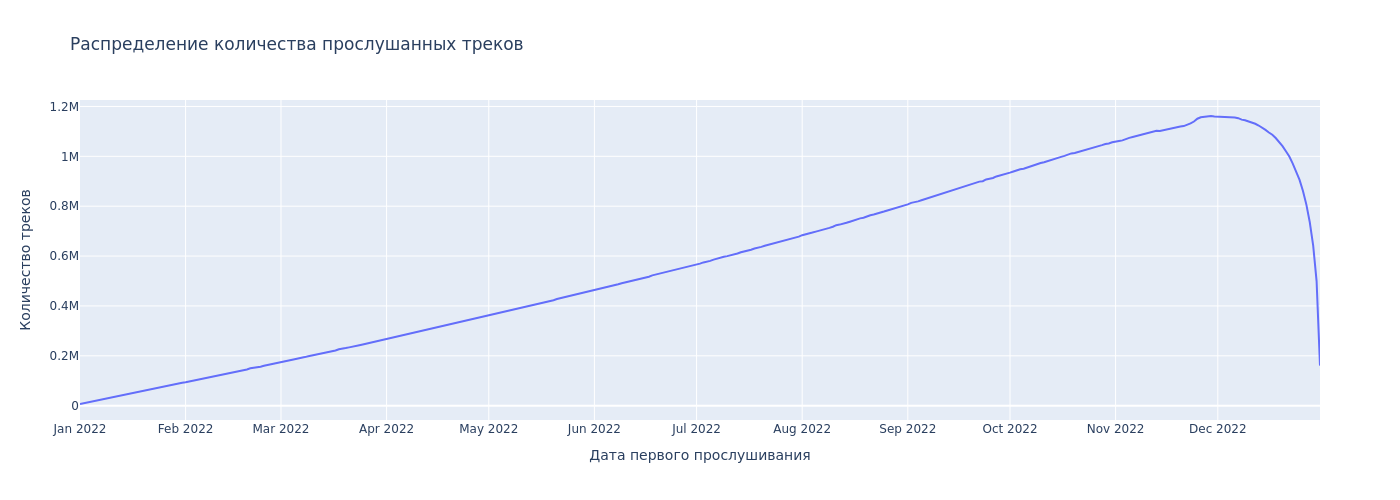

In [57]:
fig = interactions.groupby(by="started_at")["track_id"].count().plot(
    title="Распределение количества прослушанных треков",
    labels={"started_at": "Дата первого прослушивания", "value": "Количество треков"}
)
fig.update_layout(
    xaxis={"tickmode":"auto", "nticks": 12},
    height=500, width=1400, showlegend=False
)
fig.show(renderer="png")

С начала рассматриваемого периода количество прослушаний новых треков пользователей неуклонно росло до декабря 2022 года, после чего произшло резкое снижение количества таких взаимодействий. Причиной этому можно предположить, что в датасет не включались новые треки, которых не было в течение года, либо количество новых прослушиваний пользователями таких треков не доходило до 5. Оценим распределение прослушиваний треков пользователями.

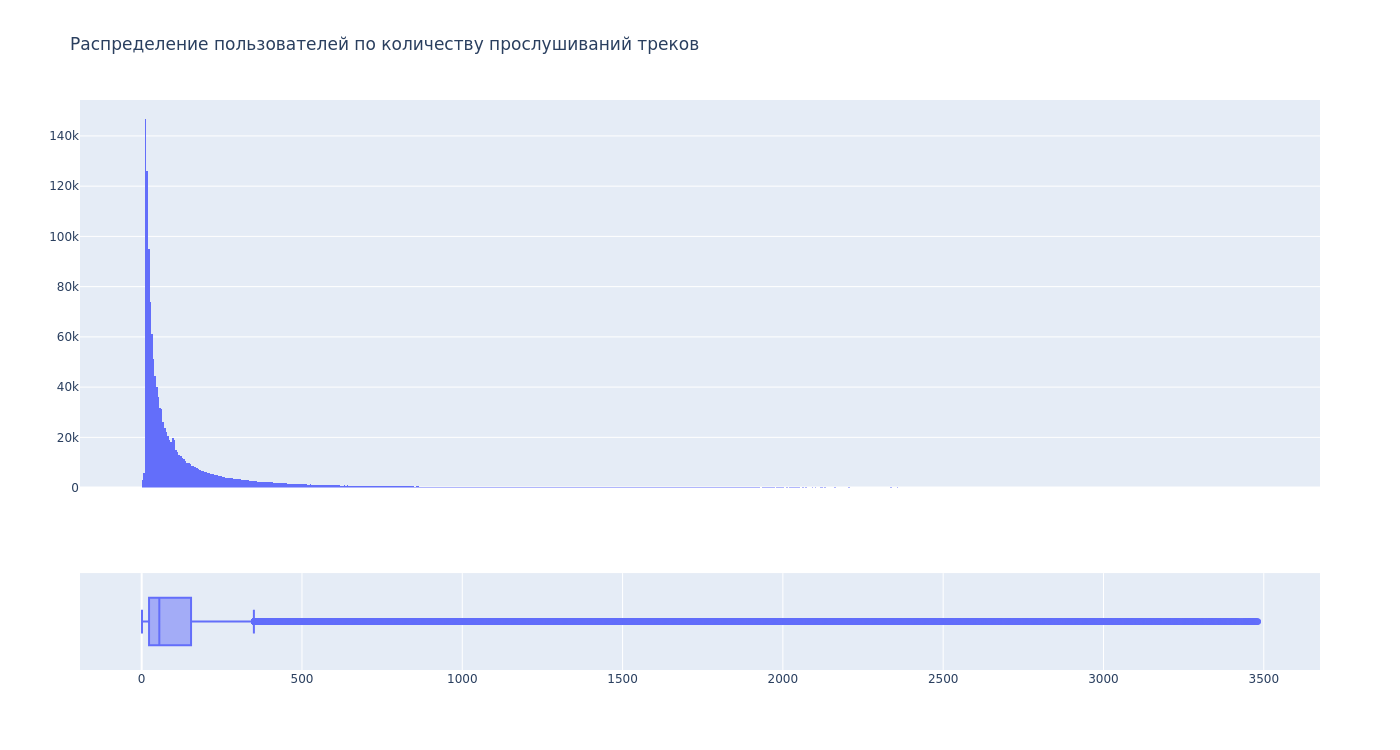

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Треков на пользователя:,1373221.00,155.20,286.53,1.00,11.00,12.00,23.00,55.00,154.00,640.00,1477.00,3482.00


In [58]:
user_tracks = interactions.groupby(by="user_id")["track_id"].count().rename("Треков")
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.8, 0.2])
fig.add_trace(user_tracks.plot(kind="hist").data[0], row=1, col=1)
fig.add_trace(
    trace=user_tracks.plot(x="Треков", kind="box").data[0],
    row=2, col=1)
fig.update_layout(
    height=750, width=1400, showlegend=False,
    title_text="Распределение пользователей по количеству прослушиваний треков")
fig.show(renderer="png")
interactions.groupby(by="user_id")["track_id"].count() \
    .rename("Треков на пользователя:") \
    .describe(percentiles=PERCENTILES).to_frame().T

Заметно, что пользователи в основной массе прослушивают не более 350 новых треков, причем значения больше сдвинуты к минимальным - от 10 и выше. Однако остается довольно большое количество пользователей, которые превышают основную массу по количеству прослушиваний.

### Наиболее популярные треки

In [59]:
top_20 = interactions.groupby(by="track_id")["user_id"].count() \
    .rename("popularity").sort_values(ascending=False).head(20)
tracks[tracks["track_id"].isin(top_20.index.to_list())].groupby(
    ["track_id", "track_name"])[["album_name", "artist_name", "genre_name"]] \
        .first().merge(top_20.reset_index(), on="track_id") \
        .sort_values("popularity", ascending=False)

,track_id,album_name,artist_name,genre_name,popularity
1,53404,Nevermind,Nirvana,alternative,109687
10,33311009,Shape Of Pop,Imagine Dragons,rock,105836
2,178529,Meteora,Linkin Park,numetal,100647
11,35505245,I Got Love,Miyagi & Эндшпиль,rusrap,98885
19,65851540,Юность,Dabro,pop,86290
7,24692821,Way down We Go,KALEO,indie,85223
9,32947997,Shape of You,Ed Sheeran,pop,85049
15,51241318,In the End,Tommee Profitt,rnb,84389
13,45499814,Life,Zivert,pop,84168
4,795836,Ten Summoner's Tales,Sting,pop,83884


В двадцатку наиболее популярных треков за весь период входят треки, с которыми взаимодействовали более 70 и до 110 тысяч пользователей.

### Наиболее популярные жанры

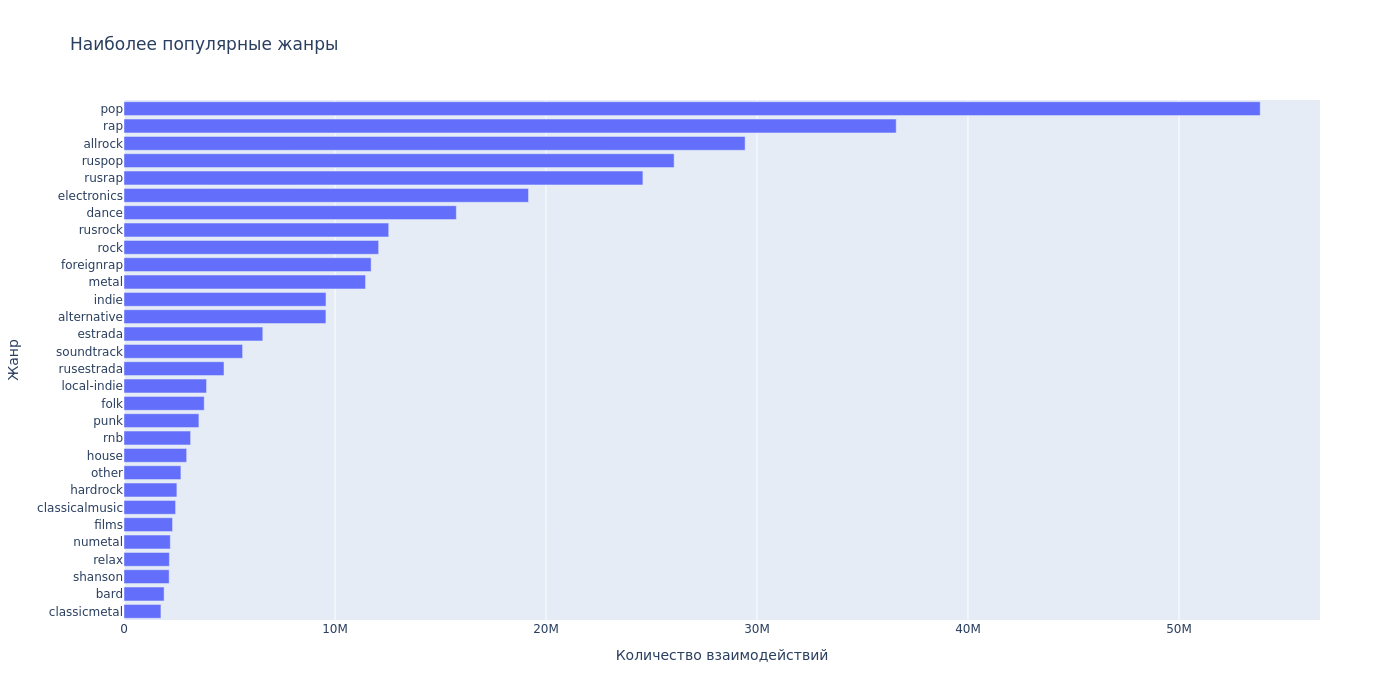

In [60]:
fig = tracks.merge(
    right=interactions.groupby("track_id")["user_id"].count() \
        .rename("popularity").reset_index(),
    on="track_id"
).drop_duplicates(subset=["track_id", "genre"]) \
    .groupby(by=["genre", "genre_name"])["popularity"].sum() \
    .sort_values(ascending=False).reset_index(level=1).head(30).plot(
        x="popularity", y="genre_name", kind="barh", 
        title="Наиболее популярные жанры",
        labels={"popularity": "Количество взаимодействий", "genre_name": "Жанр"}
    )
fig.update_layout(
    height=700, width=1400, yaxis={"autorange": "reversed"}
)
fig.show(renderer="png")

Наиболее популярным жанром является pop, что следует из названия этого жанра (popular). Этот жанр по количеству взимодействий с большим отрывом выходит вперед по сравнению с остальными жанрами - более 50 миллионов прослушиваний пользователями. Далее по популярности идут жанры rap, allrock, ruspop и rusrap, которые превышают отметку в 20 миллионов прослушиваний.

### Треки, которые никто не прослушал

In [61]:
tracks.groupby(by=["track_id", "track_name"])["artist_name"] \
    .agg(lambda x: x.unique()).reset_index(level=1).join(
        interactions.groupby("track_id")["user_id"].count().rename("popularity")
    ).loc[lambda x: x["popularity"].isna()].fillna(0)

,track_name,artist_name,popularity
track_id,,,
811742,Love Ain't Nothing But A Four Letter Word,[Bon Jovi],0.00
4552879,Accarezzami,"[Italian Ballroom, Bob Roscato]",0.00
6153960,Pimps And Hookers,[NOFX],0.00
33330679,Торопись,[Евгений Осин],0.00
34641441,Цветы на дорогах войны,[Павел Смеян],0.00
47039584,73rdAnnualGimbleTelathon,[BONES],0.00


Как уже отмечалось ранее, все треки в датасете имели не менее 5 прослушиваний. Вероятно это ограничение, по которому осуществлялась выгрузка датасета. Однако после очистки датасета по пользователям с очень большим количеством взаимодействий появилось несколько треков без прослушиваний. Оценим новое распределение прослушиваний по трекам.

In [62]:
tracks.groupby(by=["track_id", "track_name"])["artist_name"] \
    .agg(lambda x: x.unique()).reset_index(level=1).join(
        interactions.groupby("track_id")["user_id"].count().rename("popularity")
    ).loc[lambda x: ~x["popularity"].isna()].describe(percentiles=PERCENTILES).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
popularity,999994.00,213.12,1344.76,1.00,4.00,5.00,8.00,17.00,61.00,714.00,3776.00,109687.00


Порядка 5% треков не превышает 4-х прослушиваний за исследуемый период, 75% треков немного превышает 60 прослушиваний, и только для менее 1% треков количество прослушиваний превышает 3,8 тысяч.

## Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций. По трекам сохраним только первые сведения по альбомам и артистам, чтобы не сохранять избыточные данные, но можно было быстро оценить сведения по треку если они понадобится в дальнейшем. Сохраним также и id жанров в виде списка для последующего использования при подготовке признаков.

> Изначально пытался сохранить все сведения переведя их в словари формата {id: "name", id: "name"} по каждому полю. Использовал следующие преобразования для каждого поля - album, artist и genre:
```python
    # Преобразование альбомов
    albums = tracks[["track_id", "album", "album_name"]].drop_duplicates()
    albums["albums"] = albums.apply(
        lambda x: np.nan if np.isnan(x["album"]) else (str(x["album"]), x["album_name"]), 
        axis=1)
    albums = albums.groupby("track_id")["albums"].agg(lambda x: dict(x.dropna().to_list()[:2]))
```
> После чего объединял с уникальными треками по track_id, однако не получилось сохранить в parquet файл - постоянно падало ядро из-за нехватки памяти, обработка таких данных при сохранении производилась очень долго. Соответственно решил оставить только первые значения по каждому треку.

In [63]:
# Исключение лишних столбцов и сборка треков 
# с сохранением первых наименований и списка жанров
tracks = tracks.drop(columns=["album", "artist", "genre_name"]) \
    .groupby("track_id").agg({
        "track_name": "first", 
        "album_name": "first", 
        "artist_name": "first", 
        "genre": lambda x: list(set(x.astype(np.int32)))
    })
tracks

,track_name,album_name,artist_name,genre
track_id,,,,
26,Complimentary Me,Taller Children,Elizabeth & the Catapult,"[11, 21]"
38,Momma's Boy,Taller Children,Elizabeth & the Catapult,"[11, 21]"
135,Atticus,Wild Young Hearts,Noisettes,[11]
136,24 Hours,Wild Young Hearts,Noisettes,[11]
138,Don't Upset The Rhythm (Go Baby Go),Wild Young Hearts,Noisettes,[11]
...,...,...,...,...
101478482,На лицо,На лицо,FLESH,"[75, 3]"
101490148,Без капли мысли,Без капли мысли,Даня Милохин,"[11, 20]"
101493057,SKITTLES,SKITTLES,WhyBaby?,"[75, 44]"


In [64]:
# Удаление треков, по которым нет прослушиваний
tracks = tracks.merge(
    interactions.groupby("track_id")["user_id"].count(),
    how="inner", on="track_id").reset_index().rename(
        columns={
            "track_id": "item_id", 
            "track_name": "name",
            "album_name": "album",
            "artist_name": "artist"}
    ).drop(columns="user_id")
tracks

,item_id,name,album,artist,genre
0,26,Complimentary Me,Taller Children,Elizabeth & the Catapult,"[11, 21]"
1,38,Momma's Boy,Taller Children,Elizabeth & the Catapult,"[11, 21]"
2,135,Atticus,Wild Young Hearts,Noisettes,[11]
3,136,24 Hours,Wild Young Hearts,Noisettes,[11]
4,138,Don't Upset The Rhythm (Go Baby Go),Wild Young Hearts,Noisettes,[11]
...,...,...,...,...,...
999989,101478482,На лицо,На лицо,FLESH,"[75, 3]"
999990,101490148,Без капли мысли,Без капли мысли,Даня Милохин,"[11, 20]"
999991,101493057,SKITTLES,SKITTLES,WhyBaby?,"[75, 44]"
999992,101495927,Москва,Москва,Yanix,"[75, 3]"


Данные о взаимодействиях оставим как есть, только переименуем названия столбцов. Для обучения модели понадобятся сведения о порядке прослушивания элементов, который мы преобразуем  на тренировочной выборке.

In [65]:
# Переименование столбцов
interactions.rename(columns={"track_id": "item_id", "track_seq": "item_seq"}, inplace=True)
interactions

,user_id,item_id,item_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22
...,...,...,...,...
287,1374582,95514767,288,2022-12-29
288,1374582,97220301,289,2022-12-29
289,1374582,97241171,290,2022-12-29
290,1374582,98542641,291,2022-12-29


## Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [66]:
# Сохранение треков и взаимодействий
save_data(tracks, "items.parquet", "data")
save_data(interactions, "events.parquet", "data")

In [67]:
# Проверка наличия файлов в S3
if S3:
    fs = s3fs.S3FileSystem(** STORAGE_OPTIONS)
    display(fs.ls(f"s3://{S3_BUCKET}/recsys/data"))
else:
    display(os.listdir("data"))

['s3-student-mle-20240822-6db01ad632/recsys/data/events.parquet',
 's3-student-mle-20240822-6db01ad632/recsys/data/items.parquet']

## Очистка памяти

In [68]:
# Остановка ядра для его перезапуска
exit()

# === ЭТАП 3 ===

> ⚠️ **ВАЖНО!!!** 
> Для выполнения последующего кода необходимо перезапустить ядро Python. После перезапуска необходимо выполнить все ячейки из раздела `Инициализация` для загрузки библиотек и констант.

## Загрузка данных

Файл events.parquet содержит основные данные для получения рекомендаций, загрузку будем производить частично средствами pyarrow, который позволяет фильтровать данные при их загрузке. При необходимости будем подгружать датасет items.parquet. Для загрузки данных из файлов подготовлена следующая функция:

In [ ]:
# Функция загрузки данных, необходимо выполнить данную ячейку 
# после последующего перезапуска ядра Python

def load_data(
        file_name: str, dir_name: str, 
        columns = None, filters = None,
        s3: bool = S3, bucket = S3_BUCKET, 
        storage_options = STORAGE_OPTIONS) -> pd.DataFrame:
    """
    Функция для загрузки датасета pandas по указанному имени файла `file_name` 
    из указанной директории `dir_name`. Параметр `s3` регулирует загрузку локально или 
    из директории 'recsys' хранилища S3 указанного `bucket` с применением `storage_options`.
    Параметр `columns` - список загружаемых столбцов.
    Параметр `filters` - фильтр вида `[('user_id', 'in', var), ...]`
    """
    if s3:
        return pd.read_parquet(
            f"s3://{bucket}/recsys/{dir_name}/{file_name}",
            engine="pyarrow",
            storage_options=storage_options, 
            columns=columns, filters=filters
        )
    else:
        return pd.read_parquet(
            f"../{dir_name}/{file_name}", 
            engine="pyarrow",
            columns=columns, filters=filters
        )

## Разбиение данных

Разобьем данные по указанной в постановке в задачи дате разбиения. Все значения ранее этой даты будут использованы для тренировки модели ALS, а значения с даты разбиения и выше в качестве отложенной тестовой выборки. Для начала загрузим и оценим тестовую выборку.

In [7]:
# Загрузка тестовой выборки
test = load_data(
    "events.parquet", "data",
    filters=[("started_at", ">=", SPLIT_DATE)]
)

# Сведения о выборке
print(f"Количество взаимодействий в тестовой выборке: {test.shape[0]:,.0f}")

# Получение сведений о пользователях и треках из выборки
test_users = test["user_id"].unique()
print(f"Количество уникальных пользователей: {len(test_users):,.0f}")
test_items = test["item_id"].unique()
print(f"Количество уникальных треков: {len(test_items):,.0f}")

Количество взаимодействий в тестовой выборке: 13,898,646
Количество уникальных пользователей: 783,525
Количество уникальных треков: 594,326


На тестовую выборку приходится более 13 миллионов прослушиваний треков, количество пользователей менее 800 тысяч, а треков менее 600 тысяч.

Оценим тренировочную выборку.

In [8]:
# Загрузка тренировочной выборки
train = load_data(
    "events.parquet", "data",
    filters=[("started_at", "<", SPLIT_DATE)]
)

print(f"Количество записей в тренировочной выборке {train.shape[0]:,.0f}")
print(f"Количество уникальных пользователей: {train['user_id'].nunique():,.0f}")
print(f"Количество уникальных треков: {train['item_id'].nunique():,.0f}")

Количество записей в тренировочной выборке 199,219,097
Количество уникальных пользователей: 1,342,566
Количество уникальных треков: 999,627


Количество записей в тренировочном датасете не доходит до 200 миллионов, пользователей порядка 1.3 миллиона, а треков менее 1 миллиона. Оценим распределение количества прослушиваний треков в датасете.

In [9]:
train_info = pd.DataFrame()
train_info["Пользователей на трек"] = train.groupby(by="item_id")["user_id"].count() \
    .describe(percentiles=PERCENTILES)
train_info["Треков на пользователя"] = train.groupby(by="user_id")["item_id"].count() \
    .describe(percentiles=PERCENTILES)
train_info.T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Пользователей на трек,999627.00,199.29,1268.62,1.00,3.00,4.00,7.00,16.00,56.00,665.00,3544.00,108651.00
Треков на пользователя,1342566.00,148.39,278.91,1.00,5.00,10.00,20.00,51.00,146.00,619.00,1441.00,3400.00


Тренировочный датасет содержит небольшое количество пользователей и треков, у которых всего одно прослушивание за выбранный период. Порядка 95% треков прослушивались не менее 4 раз, а по пользователям не менее 99% пользователей слушали не менее 5 треков. Основная масса пользователей за период прослушивала до тысячи треков, однако имеются пользователи, которые слушали более 3.5 тысяч треков. 

Для персональных рекомендаций определим порог по количеству треков на пользователя - `5 треков`, исключим пользователей, прослушавших меньше порога.

In [10]:
USER_THR = 5
users_to_exclude = train.groupby(by="user_id")["item_id"].count() \
    .sort_values(ascending=True).loc[lambda x: x < USER_THR]
users_to_exclude

user_id
399088     1
811020     1
1043105    1
756238     1
381045     1
          ..
656084     4
712054     4
293950     4
249415     4
676488     4
Name: item_id, Length: 9982, dtype: int64

Без малого 10 тысяч пользователей прослушало меньше 5 треков. Исключим таких пользователей из тренировочной выборки, и сохраним сведения по трекам для онлайн рекомендаций.

In [11]:
# Исключение теплых пользователей из датасета
online_ids = train["user_id"].isin(users_to_exclude.index.to_list())
online_events = train[online_ids].copy()
train = train[~online_ids].copy()

del online_ids

print(f"Количество записей удалено: {online_events.shape[0]}")
print(f"Осталось записей в тренировочной выборке {train.shape[0]:,.0f}")
print(f"Количество уникальных пользователей: {train['user_id'].nunique():,.0f}")
print(f"Количество уникальных треков: {train['item_id'].nunique():,.0f}")

Количество записей удалено: 26826
Осталось записей в тренировочной выборке 199,192,271
Количество уникальных пользователей: 1,332,584
Количество уникальных треков: 999,627


Выборка сократилась незначительно - менее 27 тысяч записей, а по трекам - не сократилась вообще. Оценим количество пользователей и треков, которые не вошли в тренировочную выборку, но имеются в тестовой, а также количество горячих пользователей в тестовой выборке.

In [12]:
train_users = train["user_id"].unique()
train_items = train["item_id"].unique()

test_new_users = list(set(test_users) - set(train_users))
test_new_items = list(set(test_items) - set(train_items))
test_hot_users = list(set(test_users) & set(train_users))

print("Количество новых пользователей:",
      f"{len(test_new_users):,.0f}")
print("Количество горячих пользователей:",
      f"{len(test_hot_users):,.0f}")
print("Количество новых треков:",
      f"{len(test_new_items):,.0f}")

Количество новых пользователей: 38,928
Количество горячих пользователей: 744,597
Количество новых треков: 367


Количество пользователей составляет без малого 39 тысяч, а горячих пользователей порядка 742.5 тысячи. Новых треков в тестовой выборке 452, взглянем на эти треки.

In [13]:
new_tracks = load_data(
    "items.parquet", "data",
    columns=["name", "album", "artist"],
    filters=[("item_id", "in", test_new_items)]
)

new_tracks.join(test.groupby("item_id")["user_id"].count().rename("popularity")) \
    .sort_values(by="popularity", ascending=False)

,name,album,artist,popularity
141,Down,Perfectly Preserved Live (Release Event 2/12/2021),Love and Death,1.00
327,PRAYER,HEADING SOUTH,PRXSXNT FXTURE,1.00
364,I LOVE YOU,I LOVE YOU,Рекорд Оркестр,1.00
0,Riding On The Wings Of My Lord,Mama Said,Lenny Kravitz,NaN
1,Кабо Абэ,Всевозможно,Сансара,NaN
...,...,...,...,...
361,Wild Battle (R/S/E),Wild Battle (R/S/E),RichaadEB,NaN
362,Вселенная,Вселенная,Саша Зверева,NaN
363,Главное — не победа!,Закат империи,unknown,NaN
365,ГОРЯТ ТАНЦПОЛЫ,ГОРЯТ ТАНЦПОЛЫ,ЗАВТРА БРОШУ,NaN


Новые треки в тестовой выборке не превышают 12 прослушиваний пользователями.

In [14]:
# Удаление переменных
del test, test_new_items, test_new_users, new_tracks, test_items, test_users, \
    train_info, train_items, train_users, users_to_exclude

## Топ популярных

Рассчитаем популярность треков из тренировочной выборки.

In [15]:
top_popular = train.groupby(by="item_id")["user_id"] \
    .nunique().sort_values(ascending=False).rename("popularity")
top_popular

item_id
53404       108565
33311009     99958
178529       99531
35505245     94872
24692821     83094
             ...  
10107354         1
99488081         1
91715448         1
45753865         1
91707378         1
Name: popularity, Length: 999627, dtype: int64

Самый популярный трек тренировочной выборки имеет почти 110 тысяч прослушиваний, последние треки имеют только по одному прослушиванию. Взглянем на наиболее популярные треки.

In [16]:
# Загрузка информации о треках
top_tracks = load_data(
    "items.parquet", "data",
    columns=["item_id", "name", "album", "artist"],
    filters=[("item_id", "in", top_popular.index.to_list())]
).set_index("item_id")

top_tracks.join(top_popular).sort_values("popularity", ascending=False).head(20)

,name,album,artist,popularity
item_id,,,,
53404,Smells Like Teen Spirit,Nevermind,Nirvana,108565
33311009,Believer,Shape Of Pop,Imagine Dragons,99958
178529,Numb,Meteora,Linkin Park,99531
35505245,I Got Love,I Got Love,Miyagi & Эндшпиль,94872
24692821,Way Down We Go,Way down We Go,KALEO,83094
795836,Shape Of My Heart,Ten Summoner's Tales,Sting,82558
6705392,Seven Nation Army,Elephant,The White Stripes,79426
32947997,Shape of You,Shape of You,Ed Sheeran,79375
37384,Zombie,Stars: The Best Of The Cranberries 1992-2002,The Cranberries,78224


В целом значения близкие как для всего датасета. Для дальнейшего использования масштабируем популярность треков путем преобразования в значения до `1` для самого популярного трека.

In [17]:
# Масштабирование популярности треков
top_popular = (top_popular / top_popular.max()).astype(np.float32)
top_popular = top_popular.reset_index()
top_popular

,item_id,popularity
0,53404,1.00
1,33311009,0.92
2,178529,0.92
3,35505245,0.87
4,24692821,0.77
...,...,...
999622,10107354,0.00
999623,99488081,0.00
999624,91715448,0.00
999625,45753865,0.00


Сохраним ТОП популярных треков в файл `top_popular.parquet` по пути `recsys/recommendations/` хранилища S3.

In [18]:
# Сохранение датасета
save_data(top_popular, "top_popular.parquet", "recommendations")

In [19]:
# Удаление переменных
del top_popular, top_tracks

## Персональные

Рассчитаем персональные рекомендации.

Для обучения модели ALS будем использовать сведения о порядке прослушивания треков и возможно комбинировать с количеством треков на пользователя. Желательно провести такое преобразование значений, чтобы более поздние треки и пользователи с малым количеством треков имели большую важность для модели. ALS не требует масштабирования данных, но следует протестировать различные ограничения по нижнему значению. Также для большего разброса весов можно применить гиперпараметр alpha.

Оценим графики различных функций, в том числе соотнесем их с графиком распределения пользователей по количеству их взаимодействий.

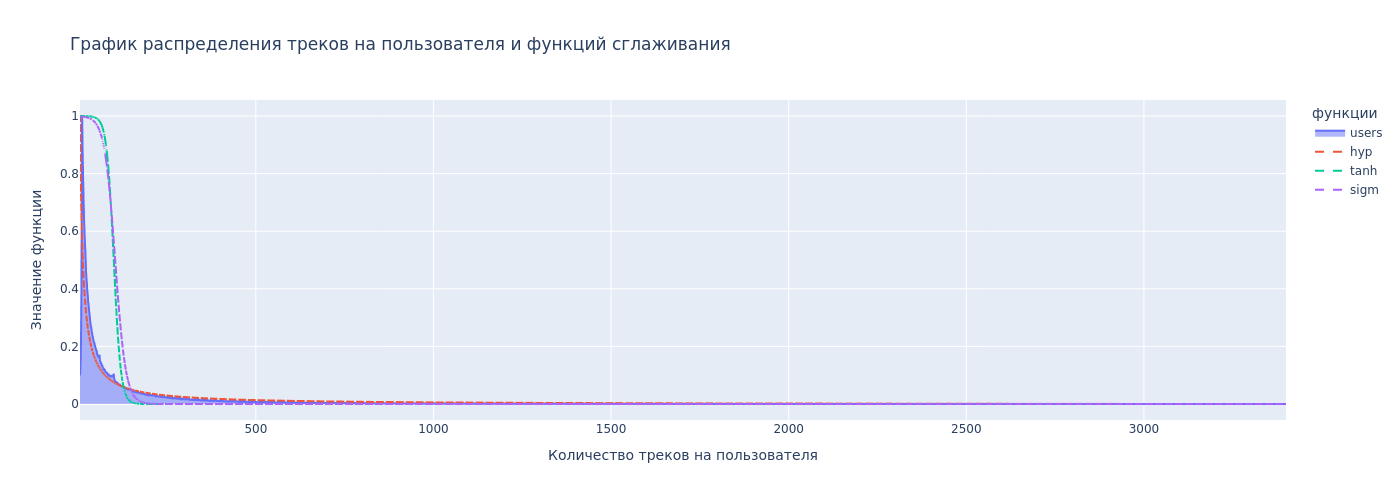

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
users,3268.00,0.01,0.05,0.00,0.00,0.00,0.00,0.00,0.00,0.04,0.24,1.00
hyp,3268.00,0.01,0.05,0.00,0.00,0.00,0.00,0.00,0.01,0.04,0.19,1.00
tanh,3268.00,0.03,0.16,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00
sigm,3268.00,0.03,0.16,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.99,1.00


In [20]:
# Гиперболическое сглаживание
def hyp_smoothing(value, min=0, b=8):
    value = value - np.min(value)
    max = np.max(value)
    f_min = 1 / (b + max)
    return (
        min + (1 / (b + value) - f_min) / (1/b - f_min) * (1 - min)
    ).astype(np.float32)

# Гиперболический тангенс (обратный)
def tanh_smoothing(value, min=0, a=100, b=20):
    return (
        1 - (1 - min) * (np.tanh((value - a) / b) + 1) / 2
    ).astype(np.float32)

# Сигмоидная функция (обратная)
def sigm_smoothing(value, min=0, a=100, b=15):
    value = value - np.min(value) + 1
    return (
        (1 - min) / (1 + np.exp(-(a - value) / b))
    ).astype(np.float32)

smoothing = train.groupby("user_id")["item_id"].count() \
    .sort_values().to_frame().reset_index() \
    .rename(columns={"user_id": "users", "item_id": "items"})
smoothing["users"] = smoothing.groupby("items")["users"].transform("count")
smoothing["users"] = smoothing["users"] / smoothing["users"].max()
smoothing.drop_duplicates(inplace=True)
smoothing["hyp"] = hyp_smoothing(smoothing["items"])
smoothing["tanh"] = tanh_smoothing(smoothing["items"])
smoothing["sigm"] = sigm_smoothing(smoothing["items"])
smoothing.set_index("items", inplace=True)

fig = smoothing.plot(
    title="График распределения треков на пользователя и функций сглаживания",
    labels={"value": "Значение функции", "items": "Количество треков на пользователя"}
)
for trace in fig.data:
    if trace.name != "users":
        trace.line.dash = "dash"
    else:
        trace.fill = "tozeroy"
fig.update_layout(height=500, width=1400, legend_title_text="функции")
fig.show(renderer="png")
smoothing.describe(PERCENTILES).T

Гипербола довольно близко походит на распределение количества прослушанных треков, однако начинает свое снижение сразу, сдвигом на 10-15 треков можно получить более близкое их соответствие. Гиперболический тангенс имеет довольно крутые, а сигмоида более плавные переходы. При этом сигмоиду можно сделать асимметричной используя обобщенную логистическую функцию. 

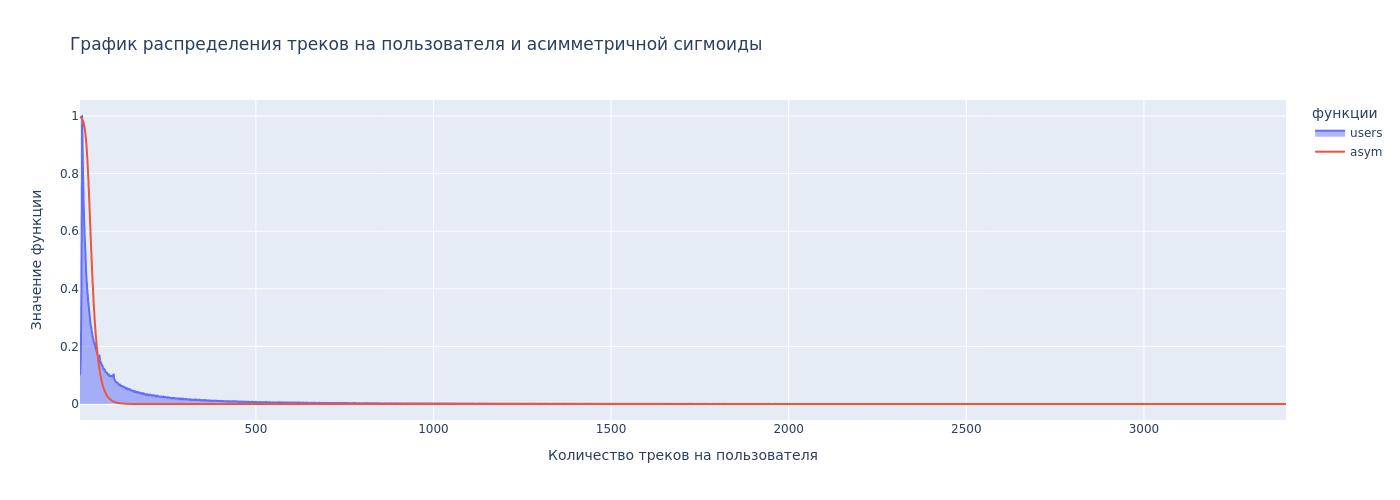

In [21]:
# Обобщенная логистическая функция (обратная)
def asym_smoothing(value, min=0, q=0.01, a=5, b=5, c=1/3):
    # ограничиваем сверху для экспоненты
    value = np.clip(value, None, 3500)
    return (
        min + (1 - min) / ((1 + q * np.exp(-(a - value) / b)) ** c)
    ).astype(np.float32)

smoothing["asym"] = asym_smoothing(smoothing.index, min=0)
fig = smoothing[["users", "asym"]].plot(
    title="График распределения треков на пользователя и асимметричной сигмоиды",
    labels={"value": "Значение функции", "items": "Количество треков на пользователя"}
)
fig.update_traces(selector={"name": "users"}, fill="tozeroy")
fig.update_layout(height=500, width=1400, legend_title_text="функции")
fig.show(renderer="png")

Данная функция лучше подойдет для весов по новизне треков, что позволит самым последним трекам установить больший вес, а прослушанным давно - меньший. Но для этого нумерацию треков необходимо сделать обратной.

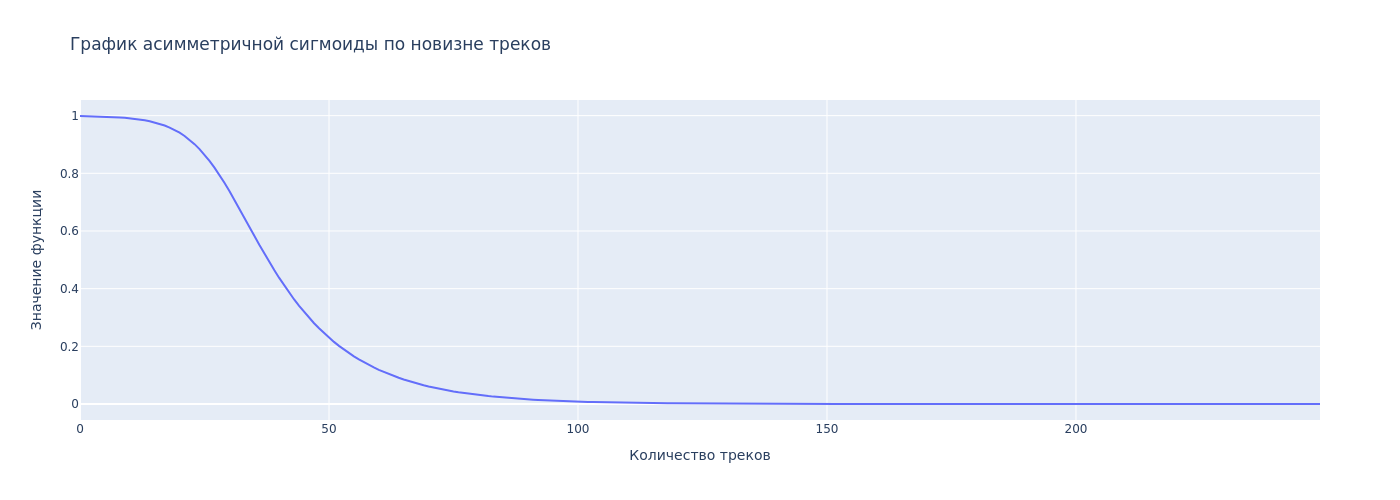

In [22]:
fig = pd.Series(asym_smoothing(range(250))).plot(
    title="График асимметричной сигмоиды по новизне треков",
    labels={"value": "Значение функции", "index": "Количество треков"}
)
fig.update_layout(height=500, width=1400, showlegend=False)
fig.show(renderer="png")

Применение такой фукнции к обратной нумерации треков у пользователя позволит учесть порядок событий и не занизит веса взаимодействий у пользователей с малым количеством, а также довольно сильно снизит влияние старых треков для пользователей с их большим количеством, что не требует дополнительно комбинировать ее с весами на основании количества треков на пользователя.

> Пробовал комбинировать с гиперболой со сдвигом в 15 треков:

```python
# Гиперболическая функция с добавлением сдвига
def hyp_smoothing(value, min=0.9, offset=15, b=8):
    value = np.clip(value, offset, None)
    max = np.max(value)
    f_min = 1 / (b + max - offset)
    return min + (1 - min) * (1 / (b + value - offset) - f_min) / (1/b - f_min)
```

> График этой функции выглядит достаточно близко к графику распределения пользователей по количеству прослушиваний. Целью было снизить веса наиболее активных пользователей путем комбинации двух функций в одном весе - одной по новизне треков с применением асимметричной сигмоиды, другой по количеству треков на пользователя с применением гиперболы со сдвигом. Протестировано с разным соотношением, однако общее количество пользователей с позитивными рекомендациями для ранжирующей модели снижается при комбинации. Оставил только асимметричную сигмоиду по новизне треков, которая дала наибольшее количество пользователей с позитивными рекомендациями.

Оценим распределение значений весов для ALS.

In [23]:
train["weight"] = asym_smoothing(
    train.groupby("user_id")["item_seq"].transform("max") - train["item_seq"])
train["weight"].describe(percentiles=PERCENTILES).to_frame().T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
weight,199192271.00,0.21,0.36,0.00,0.00,0.00,0.00,0.00,0.23,1.00,1.00,1.00


Более 50% треков имеют минимальные значения, 3 квантиль также имеет довольно низкие значения веса, а близки к максимальному значению не менее 5% датасета.

В целях подготовки разреженной матрицы для алгоритма ALS произведем кодирование идентификаторов пользователей и треков. Для этого обучим на тренировочных данных LabelEncoder библиотеки sklearn.

In [24]:
# Обучение экодеров id 
encoders = {}
for col in ["user", "item"]:
    encoders[col] = LabelEncoder()
    encoders[col].fit(train[f"{col}_id"])

Преобразуем идентификаторы пользователей и треков.

In [25]:
for col in ["user", "item"]:
    train[f"{col}_id"] = encoders[col].transform(train[f"{col}_id"]).astype(np.int32)

Подготовим разреженную матрицу.

In [26]:
train_sm = scipy.sparse.csr_matrix(
    (train["weight"], (train["user_id"], train["item_id"]))
)

del train

Обучим модель ALS

In [ ]:
# Если модель уже сохранена, будет использоваться сохраненная модель
if os.path.exists("../models/als_model_train.pkl"):
    with open("../models/als_model_train.pkl", "rb") as fd:
        als_model = joblib.load(fd)
else:
    # Параметры модели
    als_params ={
        "factors": 50,
        "regularization": 0.05,
        "alpha": 10,
        "iterations": 20,
        "random_state": RANDOM_STATE,
    }
    # Обучение модели
    with threadpool_limits(1, "blas"):
        als_model = AlternatingLeastSquares(**als_params)
        als_model.fit(train_sm, show_progress=False)
    # Сохранение модели
    with open("../models/als_model_train.pkl", "wb") as fd:
        joblib.dump(als_model, fd)

Получим рекомендации модели ALS для горячих пользователей. Лучше получить как можно больше рекомендаций на каждого пользователя в целях максимизации совпадения с треками из выборки c таргетами для последующего обучения модели ранжирования рекомендаций. Для сокращения времени сгенерируем только рекомендации для горячих пользователей тестовой выборки, список которых был получен на этапе разбиения данных.

In [28]:
# Получение списка перекодированных id 
# горячих пользователей тестовой выборки
user_ids_enc = encoders["user"].transform(test_hot_users)

In [29]:
%%time

# Получение рекомендаций для горячих пользователей теста
personal_als = als_model.recommend(
    user_ids_enc, train_sm[user_ids_enc], 
    filter_already_liked_items=True, N=100)

del train_sm

CPU times: user 1h 15min 40s, sys: 29min 3s, total: 1h 44min 43s
Wall time: 27min 12s


In [30]:
# Преобразование рекомендаций в табличный формат
item_ids_enc = personal_als[0] # type: ignore
als_scores = personal_als[1] # type: ignore

personal_als = pd.DataFrame({
    "user_id": user_ids_enc,
    "item_id": item_ids_enc.tolist(), 
    "score": als_scores.tolist()})

# Получение корректных id пользователя
personal_als["user_id"] = encoders["user"].inverse_transform(
    personal_als["user_id"])

# Преобразование списков 'item_id' и 'score' в строки
personal_als = personal_als.explode(["item_id", "score"], ignore_index=True)

# Приведение типов данных
personal_als["item_id"] = personal_als["item_id"].astype(np.int32)
personal_als["score"] = personal_als["score"].astype(np.float32)

# Получение корректных id треков
personal_als["item_id"] = encoders["item"].inverse_transform(
    personal_als["item_id"])

Сохраним результат в файл `personal_train.parquet` в хранилище S3 по пути `recsys/recommendations/`.

In [31]:
save_data(personal_als, "personal_train.parquet", "recommendations")

In [32]:
del personal_als, item_ids_enc, user_ids_enc, als_scores, smoothing, fig, trace

## Похожие

Рассчитаем похожие треки, они позже пригодятся для онлайн-рекомендаций. Похожие треки получим из модели ALS, которая возвращает первым тот же трек, для получения 10 похожих треков укажем `N=11` и уберем повторяющийся трек. Для сокращения времени получим похожие треки только для теплых пользователей, у которых менее 5 взаимодействий в тренировочной выборке.

In [33]:
# получение списка всех item_id (перекодированных)
item_ids_enc = encoders["item"].transform(online_events["item_id"].unique())

In [34]:
%%time

# получение предсказаний
similar = als_model.similar_items(
    item_ids_enc, N=11
)

CPU times: user 1min 56s, sys: 49.2 s, total: 2min 45s
Wall time: 42.9 s


In [ ]:
# преобразуем полученные рекомендации в табличный формат
similar_ids_enc = similar[0] # type: ignore
similar_scores = similar[1] # type: ignore

similar = pd.DataFrame({
    "item_id": item_ids_enc,
    "similar_id": similar_ids_enc.tolist(), 
    "score": similar_scores.tolist()})

# преобразование списков 'similar_id' и 'score' в строки, 
# с отбором только неодинаковых треков
similar = similar.explode(["similar_id", "score"], ignore_index=True) \
    .loc[lambda x: x["item_id"] != x["similar_id"]]

# приведение типов данных
similar["similar_id"] = similar["similar_id"].astype(np.int32)
similar["score"] = similar["score"].astype(np.float32)

In [36]:
# получеине изначальных идентификаторов
similar["item_id"] = encoders["item"].inverse_transform(similar["item_id"])
similar["similar_id"] = encoders["item"].inverse_transform(similar["similar_id"])
similar

,item_id,similar_id,score
1,57703,60103,0.99
2,57703,33860,0.99
3,57703,57725,0.99
4,57703,39497,0.99
5,57703,83999,0.99
...,...,...,...
187138,147378,170243,0.91
187139,147378,7429471,0.91
187140,147378,4426161,0.91
187141,147378,12291471,0.90


Взглянем на наиболее похожие треки по версии модели ALS, для этого возьмем пару треков из наиболее популярных - один англоязычный, другой русскоязычный.

In [37]:
item = 33311009
print("Сведения о треке:")
display(load_data(
    "items.parquet", "data",
    filters=[("item_id", "==", item)]
).set_index("item_id"))

print("Похожие треки:")
sim_tracks = similar.query(f"item_id == {item}").drop(columns="item_id")
display(load_data(
    "items.parquet", "data",
    filters=[(
        "item_id", "in", 
        sim_tracks["similar_id"].unique())]
).set_index("item_id").join(sim_tracks.set_index("similar_id")) \
    .sort_values("score", ascending=False))

Сведения о треке:


,name,album,artist,genre
item_id,,,,
33311009,Believer,Shape Of Pop,Imagine Dragons,"[102, 14]"


Похожие треки:


,name,album,artist,genre,score
item_id,,,,,
34976783,Thunder,Thunder,Imagine Dragons,"[102, 14]",0.97
32947997,Shape of You,Shape of You,Ed Sheeran,[11],0.94
29544272,Human,Human,Rag'n'Bone Man,"[25, 70]",0.93
34429475,Глубокий сон (музыка для сна),"Музыка для Сна: музыка для массажа, для спа, для релаксации",Музыка для Сна,[335],0.92
35170143,Whatever It Takes,Whatever It Takes,Imagine Dragons,"[102, 14]",0.92
2664557,Morning Light,A State Of Trance Radio Top 15 – May 2010,Nic Chagall,"[68, 86]",0.92
42197229,Natural,Natural,Imagine Dragons,"[102, 14]",0.91
35868103,Believer,The Best of Bachata Pop,Marco Lopetuso,"[138, 21]",0.91
24692821,Way Down We Go,Way down We Go,KALEO,[70],0.91


В список похожих треков к треку Believer исполнителя Imagine Dragons попали несколько других треков этого исполнителя и другие довольно известные треки - Shape of You, Human, Way Down We Go. Списки жанров для похожих треков довольно разнообразные. Также в список попали два трека для сна/релаксации, возможно пользователи наряду с остальными треками предпочитают и спокойную музыку. 

In [38]:
item = 65851540
print("Сведения о треке:")
display(load_data(
    "items.parquet", "data",
    filters=[("item_id", "==", item)]
).set_index("item_id"))

print("Похожие треки:")
sim_tracks = similar.query(f"item_id == {item}").drop(columns="item_id")
display(load_data(
    "items.parquet", "data",
    filters=[(
        "item_id", "in", 
        sim_tracks["similar_id"].unique())]
).set_index("item_id").join(sim_tracks.set_index("similar_id")) \
    .sort_values("score", ascending=False))

Сведения о треке:


,name,album,artist,genre
item_id,,,,
65851540,Юность,Юность,Dabro,"[11, 20]"


Похожие треки:


,name,album,artist,genre,score
item_id,,,,,
66869588,Краш,Краш,Клава Кока,"[11, 20]",0.96
66322065,Поболело и прошло,Поболело и прошло,HENSY,"[11, 20]",0.96
70619465,Если тебе будет грустно,Если тебе будет грустно,Rauf & Faik,"[11, 20]",0.96
63742418,Улыбка,Улыбка,PIZZA,"[11, 20]",0.96
68699912,Это не девочка,Это не девочка,SHAKHOV,"[11, 20]",0.94
64724103,Astronomia,Astronomia,CHIKY DEE JAY,"[138, 21]",0.94
69453827,Юность,Юность,Dabro,"[11, 20]",0.93
36675033,Одна на двоих,Всё равно моя,Ost Up,"[11, 20]",0.93
32518879,Snow,Snow,Leed,"[75, 44]",0.93


Для трека Юность исполнителя Dabro можно отметить большое количество русскоязычных треков в стиле хип-хоп/рэп, в том числе одноименный трек этого исполнителя, который имеет другой ID. Однако имеются пара треков, которые сильно отличаются от остальных - Atronomia от Chiky Dee Jay и Jack Rabbit исполнителя Elton John.

Сохраним результат в файл `similar.parquet` в хранилище S3 по пути `recsys/recommendations/`.

In [39]:
save_data(similar, "similar.parquet", "recommendations")

In [40]:
del similar, item_ids_enc, similar_ids_enc, similar_scores

## Построение признаков

Построим признаки для ранжирующей модели. В качестве признака будем использовать ранее полученные персональные рекомендации. Также добавим признаки треков и пользователя. 

### Кандидаты для обучения

Для начала разделим отложенную тестовую выборку на выборку для таргетов ранжирующей модели и новую тестовую выборку. Тестовая выборка содержит данные с 16 декабря 2022 года и в это время наблюдается очень сильное ежедневное снижение по количеству новых событий у пользователей. Если разделять по дате, то в новой тестовой выборке будет существенно меньше событий, лучше разделим тестовую выборку по количеству событий на пользователя. Делить датасет будем на две близкие по количеству событий по каждому пользователю, но границу разделения округлим вверх, чтобы получить больше данных для таргетов ранжирующей модели. При этом все пользователи, которые не относятся к `горячим` и отсутствуют в тренировочной выборке - попадут в новую тестовую выборку. Функция разделения на выборку с таргетами и новую тестовую выборку вынесена в раздел `Инициализация` для возможности ее дальнейшего использования после перезагрузки ядра.

In [41]:
# Загрузка тестовой выборки
test = load_data(
    "events.parquet", "data",
    filters=[("started_at", ">=", SPLIT_DATE)]
)

In [42]:
# Разделение на таргет и тест
target, test = split_target_test(
    test, 
    encoders["user"].classes_)

# Вывод описания датасетов
for df_name, df in {"target": target, "test": test}.items():
    print(f"Пользователей в '{df_name}': {df['user_id'].nunique():,.0f}")
    print(f"Треков в '{df_name}': {df['item_id'].nunique():,.0f}")
    print(f"Всего событий в '{df_name}': {df.shape[0]:,.0f}")
    print("Распределение событий на пользователя:")
    display(
        df.groupby("user_id")["item_id"].count().rename("items by user:") \
            .describe(PERCENTILES).to_frame().T
    )
    print()

del df_name, df

Пользователей в 'target': 744,597
Треков в 'target': 461,492
Всего событий в 'target': 6,546,081
Распределение событий на пользователя:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
items by user:,744597.00,8.79,14.36,1.00,1.00,1.00,1.00,3.00,9.00,41.00,69.00,341.00



Пользователей в 'test': 654,290
Треков в 'test': 458,952
Всего событий в 'test': 7,352,565
Распределение событий на пользователя:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
items by user:,654290.00,11.24,16.93,1.00,1.00,1.00,2.00,4.00,13.00,49.00,75.00,341.00


Оценим какое количество треков приходится на пользователя в тартегете.

Уникальных пользователей в таргете более 744 тысяч, что больше пользователей из новой тестовой выборки - 654 тысячи. Это говорит о том, что в отложенной тестовой выборке было много пользователей, которые имели всего по одному прослушиванию треков. Это заметно и по распределению количества событий на пользователя - не менее четверти пользователей таргета прослушали меньше 2-х треков, также по всем перцентилям заметен сдвиг к меньшим значениям. В тестовом датасете также остались новые пользователи, которые имеют большое количество прослушиваний, так как верхние значения количества треков на пользователя превышают количество в таргете.

Загрузим рекомендации для формирования датасета для ранжирующей модели.

In [43]:
# Загрузка файлов с рекоммендациями
personal_als = load_data("personal_train.parquet", "recommendations")

In [44]:
# Добавление таргетов к кандидатам
target["target"] = True

candidates = personal_als.merge(
    target[["user_id", "item_id", "target"]],
    on=["user_id", "item_id"], how="left")
candidates["target"] = candidates["target"].fillna(False)

print(f"Пользователей в кандидатах: {candidates['user_id'].nunique()}")

del personal_als

Пользователей в кандидатах: 744597


Количество пользователей в кандидатах соответствует их количеству в таргетах, так как рекомендации и таргеты получили только для горячих пользователей из тестовой выборки. Оценим распределение позитивных рекомендаций в выборке.

In [45]:
# Оценка распределения пользователей по положительным рекомендациям
candidates[candidates["target"]].groupby("user_id")["target"].sum() \
    .describe(PERCENTILES).to_frame().T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
target,333113.00,2.71,2.87,1.00,1.00,1.00,1.00,2.00,3.00,8.00,15.00,48.00


Количество пользователей с позитивными рекомендациями более 333 тысяч, что составляет более 44.7% всех пользователей из выборки с таргетами. Количество совпадений в основном небольшое, более 50% датасета имеет не больше 2-х совпадений из персональных рекомендаций.

Для обучения модели необходимо добавить негативных рекомендаций, лучше оставить наиболее близкие к позитивным треки. Добавим популярность жанра, чтобы поиск самых близких треков был не только по score но и по популярности.

In [46]:
# Добавление популярности жанра
top_popular = load_data("top_popular.parquet", "recommendations")
candidates = candidates.merge(top_popular, on="item_id", how="left")

del top_popular

Найдем негативные рекомендации, которые наиболее близки к позитивным, оставим по 2 рекомендации на каждое целевое событие, что внесет не сильно большой (не более 1 к 2) дисбаланс в пользу негативных рекомендаций.

In [47]:
# Функция для сохранения k похожих кандидатов на базе KDTree
def keep_k_similar(
        all_candidates, target_col="target", k=2,
        cols = ["user_id", "score", "popularity"],
        sort_ascending=(True, False, False), 
        scaling_col="user_id", scale=100):
    """
    Функция для удаления записей `'target'=False` кроме k похожих 
    на базе KDTree. 
    
    Для минимизации вероятности выбора другого id необходимо
    увеличить масштаб значений существенно больше разницы
    между значенями по остальным столбцам.

    Parameters
    ----------

    other_candidates : DataFrame
        Датасет со всеми событиями
    target : str
        Датасет с целевыми событиями
    k : int
        Количество кандидатов для сохранения
    cols : list
        Столбцы для поиска подобных событий
    scaling_col : str
        Столбец для масштабирования значений
    scale : int
        Значение для масштабирования столбца `scaling_col`

    Returns
    -------
    DataFrame
        Возвращает датасет похожих на целевые события
    """
    # Работа с копией данных
    result = all_candidates.copy()

    # Масштабирование столбцов
    result[scaling_col] = result[scaling_col] * scale

    # Разделение целевых и альтернативных событий
    target_candidates = result[result[target_col]]
    other_candidates = result[~result[target_col]]

    # Поиск и отбор наиболее близких кандидатов
    tree = scipy.spatial.KDTree(other_candidates[cols])
    _, idx = tree.query(target_candidates[cols], k=k)
    other_candidates = other_candidates.iloc[np.unique(idx.flatten())]

    # Объединение целевых и подобранных кандидатов
    result = pd.concat(
        [target_candidates, other_candidates],
        ignore_index=True) \
        .sort_values(cols, ascending=sort_ascending)

    # Возвращение id пользователей
    result[scaling_col] = (result[scaling_col] / 100).astype(np.int32)

    return result

# Получение нового списка кандидатов
candidates = keep_k_similar(candidates)
candidates

,user_id,item_id,score,target,popularity
903323,5,10731250,0.37,False,0.16
0,5,34864352,0.37,True,0.16
903324,5,109647,0.36,False,0.17
903325,9,58016005,0.04,False,0.05
1,9,57175473,0.04,True,0.05
...,...,...,...,...,...
903321,1374582,79071658,0.31,True,0.08
2557940,1374582,68348390,0.30,False,0.39
2557941,1374582,71427549,0.30,False,0.08
2557942,1374582,73376988,0.30,False,0.41


Оценим распределение целевых значений по полученной выборке.

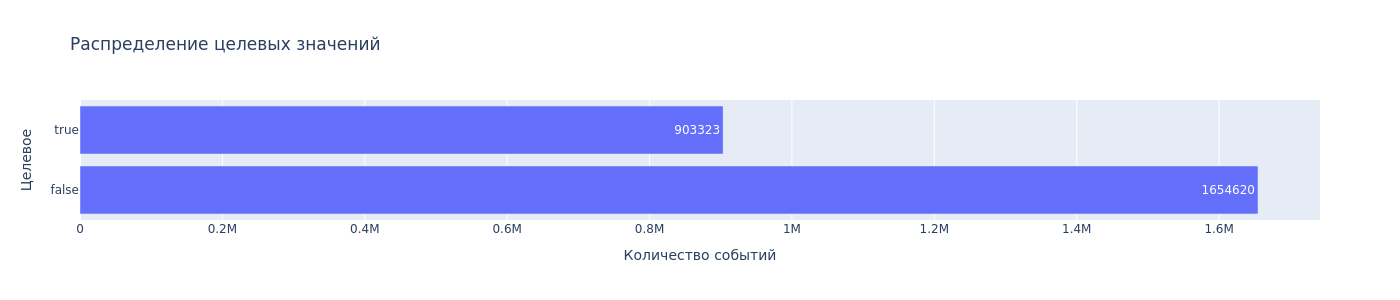

In [48]:
# График распределения целевых значений
fig = candidates["target"].value_counts().plot(
    kind="barh", text="value",
    title="Распределение целевых значений",
    labels={"target": "Целевое", "value": "Количество событий"})
fig.update_layout(height=300, width=1400, showlegend=False)
fig.show(renderer="png")
del fig

После удаления негативных рекомендаций с сохранением ближайших к позитивным имеется небольшой дисбаланс классов в пользу негативных. Больше данных для обучения модели всегда лучше, если не наблюдается сильный дисбаланс классов. Желательно использовать автоматическую балансировку весов модели ранжирования рекомендаций.

### Признаки трека

Добавим сведения о принадлежности треков к жанрам. Информация по популярности трека уже была добавлена на этапе формирования списка кандидатов. Возьмем все треки, так как данная информация нам доступна всегда.

In [49]:
# Загрузка информации по трекам
items = load_data(
    "items.parquet","data",
    columns=["item_id", "genre"])

Идентификационный номер трека не несет никакой информации о самом треке, для этого лучше использовать какие-нибудь эмбеддинги, чтобы модель выявляла закномерности по характеристикам трека, а не идентификатору. Можно взять факторы треков из модели ALS, однако для добавления треков в таком случае нужно заново обучать модель по всему датасету, при этом факторы не детерминированы и могут поменять свой смысл, что не подходит для ранжирующей модели. Хорошим решением было бы использовать AutoEncoder для генерации эмбеддингов, но в данном случае воспользуемся Truncated SVD библиотеки sklearn, который схож с методом главных компонент PCA но может быть использован для разреженных матриц.

In [50]:
# Энкодер для жанров
item_factors = items.explode("genre").rename(
    columns={"genre": "genre_id"})
encoders["genre"] = LabelEncoder()
encoders["genre"].fit(item_factors["genre_id"])

# Обучим Label Encoder на новый список треков
encoders["item"].fit(item_factors["item_id"])

# Кодирование треков и жанров
for col in ["item", "genre"]:
    item_factors[f"{col}_id"] = encoders[col].transform(
        item_factors[f"{col}_id"])

# Подготовка разреженной матрицы
item_factors = scipy.sparse.csc_matrix((
    (np.ones(item_factors.shape[0])), 
    (item_factors["item_id"], item_factors["genre_id"])
))
item_factors

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 1656335 stored elements and shape (999994, 174)>

Желательно иметь эмбеддинги для всех имеющихся треков по жанрам или другим характеристикам треков, чтобы не было проблем в дальнейшем при получении эмбеддингов для треков, не вошедших в текущую выборку с другими жанрами. Для модели установим 15 компонент (размерность эмбеддингов) на треки.

In [ ]:
# Обучение энкодера и получение эмбеддингов
item_feat_enc = TruncatedSVD(
    n_components=15, 
    random_state=RANDOM_STATE)

item_factors = pd.DataFrame(
    item_feat_enc.fit_transform(item_factors)
).reset_index().rename(columns={"index": "item_id"})

# Сохранение энкодера для дальнейшего использования
with open("../models/item_feat_enc.pkl", "wb") as fd:
    joblib.dump(item_feat_enc, fd)

# Переименование столбцов и декодирование item_id
item_factors["item_id"] = encoders["item"].inverse_transform(
    item_factors["item_id"])
item_factors.rename(columns={
    col: f"item_f{col:02d}" for col in item_factors.columns[1:]
}, inplace=True)
item_factors

,item_id,item_f00,item_f01,item_f02,item_f03,item_f04,item_f05,item_f06,item_f07,item_f08,item_f09,item_f10,item_f11,item_f12,item_f13,item_f14
0,26,0.08,0.93,-0.17,-0.01,0.00,0.00,-0.00,0.01,0.01,0.01,-0.00,0.00,0.97,0.04,-0.29
1,38,0.08,0.93,-0.17,-0.01,0.00,0.00,-0.00,0.01,0.01,0.01,-0.00,0.00,0.97,0.04,-0.29
2,135,0.08,0.93,-0.17,-0.01,-0.00,-0.01,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.06,-0.31
3,136,0.08,0.93,-0.17,-0.01,-0.00,-0.01,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.06,-0.31
4,138,0.08,0.93,-0.17,-0.01,-0.00,-0.01,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.06,-0.31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999989,101478482,1.25,-0.10,-0.00,-0.00,-0.00,-0.01,-0.66,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00
999990,101490148,0.10,1.24,-0.25,-0.02,-0.00,-0.02,-0.01,-0.02,-0.01,-0.04,0.02,-0.00,-0.03,-0.12,0.61
999991,101493057,1.19,-0.10,-0.00,-0.00,0.00,0.01,0.76,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00
999992,101495927,1.25,-0.10,-0.00,-0.00,-0.00,-0.01,-0.66,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00


Сохраним датасет с признаками для возможности дальнейшего использования без постоянного декодирования.

In [52]:
save_data(item_factors, "item_feats.parquet", "features")

Добавим факторы треков в датасет с кандидатам.

In [53]:
# Добавление факторов треков
candidates = candidates.merge(
    item_factors, on="item_id", how="left")
print(
    "Количество пропусков в датасете:",
    candidates.isna().sum().sum())

del item_factors, item_feat_enc

Количество пропусков в датасете: 0


### Пользовательские признаки

Добавим пользовательские признаки, в частности user_id заменим эмбеддингами аналогично признакам трека. Также дополнительным признаком можно добавить среднюю частоту прослушивания новых треков пользователем, как отношение количества прослушанных треков к количеству дней, между которыми эти треки были прослушаны пользователем. 

Получим сведения по трекам всех `горячих` пользователей тренировочной выборки с учетом таргетов, которые уже доступны на фазе инференса.

In [54]:
# Загрузка данных до даты разделения
user_factors = load_data(
    "events.parquet", "data",
    filters=[
        ("started_at", "<", SPLIT_DATE),
        ("user_id", "in", encoders["user"].classes_)]
)
# Добавление событий из таргета
user_factors = pd.concat(
    [user_factors, target[user_factors.columns]],
    ignore_index=True
)

Для начала получим сведения по среднему количеству прослушиваний треков в день у пользователя. Это в дальнейшем позволит освободить датасет от лишних столбцов, которые не нужны для получения данных для Truncated SVD.

In [55]:
# Получение количества треков в день
user_ipd = (
    user_factors.groupby("user_id")["item_seq"].max() / 
    ((
        user_factors.groupby("user_id")["started_at"].max() - 
        user_factors.groupby("user_id")["started_at"].min()
    ).dt.days + 1)
).rename("user_ipd").reset_index()

user_ipd["user_ipd"].describe(PERCENTILES).to_frame().T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
user_ipd,1332584.00,1.47,7.17,0.01,0.04,0.06,0.16,0.45,1.38,5.50,8.83,543.20


Основная масса пользователей прослушивают менее 10 новых треков в день, порядка 50% пользователей слушают менее 1 трека за 2 дня, немало пользователей довольно редко слушают новые треки. Однако имеются пользователи с большим выбросом по количеству прослушиваний в день - более 500. Удалим лишние столбцы, достаточно оставить только идентификаторы пользователей и треков.

In [56]:
# Удаление лишних столбцов из датасета с событиями
user_factors = user_factors[["user_id", "item_id"]]

Подготовим датасет для обучения новой модели Truncated SVD на данных по жанрам у пользователей. 

In [57]:
# Получение датасета по жанрам
user_factors = user_factors \
    .merge(items, how="left", on="item_id") \
    .drop(columns="item_id")

In [58]:
# Для метода explode не хватает свободной памяти, 
# поэтому получим датасет в 2 этапа:

def get_user_genre_weights(df: pd.DataFrame):
    """
    Функция для раскрытия списка жанров с подсчетом 
    """
    # 1. Получение словаря по жанрам с их количеством 
    # посредством Counter для всех пользователей
    result = df.groupby("user_id")["genre"] \
        .agg(lambda x: Counter(np.concatenate(x.to_numpy()))) \
        .reset_index()

    # 2. Создание нового датасета из полученного путем перебора 
    # всех строк датасета для разделения ключей и значений
    return pd.DataFrame([
        (row.user_id, genre, count)
        for row in result.itertuples()
        for genre, count in row.genre.items()
    ], columns=["user_id", "genre_id", "weight"])

user_factors = get_user_genre_weights(user_factors)

Изменим веса для модели на относительные к общему количеству прослушиваний всех жанров пользователями, чтобы пользователи с большим количеством прослушиваний не влияли на общее распределение весов.

In [59]:
user_factors["weight"] = (
    user_factors["weight"] / 
    user_factors.groupby("user_id")["weight"].transform("sum")
)
user_factors

,user_id,genre_id,weight
0,0,11,0.15
1,0,20,0.10
2,0,75,0.17
3,0,3,0.17
4,0,17,0.08
...,...,...,...
26357264,1374582,55,0.00
26357265,1374582,28,0.00
26357266,1374582,70,0.00
26357267,1374582,6,0.00


Подготовим разреженную матрицу для обучения Truncated SVD, индексы можно оставить как есть, так как SVD не критично наличие пропусков в индексации, но мы их декодируем, чтобы проще было декодировать их обратно в индексы.

In [60]:
# Декодирование идентификаторов
for col in ["user", "genre"]:
    user_factors[f"{col}_id"] = encoders[col].transform(
        user_factors[f"{col}_id"])

# Подготовка разреженной матрицы
user_factors = scipy.sparse.csr_matrix(
    (user_factors["weight"], (
        user_factors["user_id"],
        user_factors["genre_id"]))
)

 Обучим новую модель Truncated SVD. Так как у пользователей сложнее взаимодействия с жанрами возьмем 30 компонент, что позволит уловить больше взаимосвязей.

In [ ]:
# Обучение энкодера пользователей по жанрам
user_feat_enc = TruncatedSVD(n_components=30)
user_factors = pd.DataFrame(
    user_feat_enc.fit_transform(user_factors)
).reset_index().rename(columns={"index": "user_id"})

# Переименование столбцов и декодирование id
user_factors.rename(columns={
    col: f"user_f{col:02d}" for col in user_factors.columns[1:]},
    inplace=True)
user_factors["user_id"] = encoders["user"].inverse_transform(
    user_factors["user_id"])

# Сохранение энкодера, если понадобится
with open("../models/user_feat_enc.pkl", "wb") as fd:
    joblib.dump(user_feat_enc, fd)

user_factors

,user_id,user_f00,user_f01,user_f02,user_f03,user_f04,user_f05,user_f06,user_f07,user_f08,...,user_f20,user_f21,user_f22,user_f23,user_f24,user_f25,user_f26,user_f27,user_f28,user_f29
0,0,0.26,0.14,-0.03,-0.03,-0.01,-0.00,0.00,-0.00,0.01,...,-0.00,-0.00,-0.00,0.02,0.00,-0.01,0.00,-0.00,-0.01,-0.00
1,1,0.23,-0.07,0.06,-0.08,0.01,-0.05,0.06,0.03,0.00,...,-0.00,-0.00,-0.00,0.01,-0.00,0.01,-0.00,0.00,-0.00,0.00
2,2,0.06,0.03,0.19,-0.04,-0.01,-0.00,0.01,0.00,-0.02,...,-0.01,0.16,0.02,-0.01,0.02,0.00,0.00,0.01,0.01,-0.02
3,3,0.39,0.23,-0.10,-0.08,-0.01,-0.04,0.01,0.00,0.01,...,-0.00,-0.00,-0.00,-0.00,-0.01,-0.01,0.00,0.00,0.00,-0.00
4,4,0.12,0.08,0.18,0.01,-0.03,0.06,0.05,-0.00,-0.01,...,0.00,0.00,0.02,0.04,0.00,-0.00,0.00,-0.00,-0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1332579,1374578,0.29,-0.11,0.15,0.07,-0.06,0.12,-0.06,0.06,0.05,...,-0.01,-0.01,-0.01,-0.04,-0.05,-0.01,-0.00,-0.00,0.01,-0.01
1332580,1374579,0.11,0.01,0.38,-0.11,-0.02,-0.05,-0.01,0.02,0.02,...,0.00,-0.00,-0.00,0.08,-0.00,-0.02,0.00,-0.00,-0.01,0.01
1332581,1374580,0.25,0.02,0.05,0.02,0.03,-0.03,0.00,-0.03,-0.03,...,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.01,-0.00,-0.00,0.00
1332582,1374581,0.38,-0.16,-0.08,-0.07,0.09,-0.01,0.02,-0.06,-0.00,...,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.01,-0.00,0.00


Добавим пользовательские факторы по среднему количеству прослушиваний в день.

In [62]:
# Объединение факторов
user_factors = user_factors.merge(
    user_ipd, on="user_id", how="left")
user_factors

,user_id,user_f00,user_f01,user_f02,user_f03,user_f04,user_f05,user_f06,user_f07,user_f08,...,user_f21,user_f22,user_f23,user_f24,user_f25,user_f26,user_f27,user_f28,user_f29,user_ipd
0,0,0.26,0.14,-0.03,-0.03,-0.01,-0.00,0.00,-0.00,0.01,...,-0.00,-0.00,0.02,0.00,-0.01,0.00,-0.00,-0.01,-0.00,0.43
1,1,0.23,-0.07,0.06,-0.08,0.01,-0.05,0.06,0.03,0.00,...,-0.00,-0.00,0.01,-0.00,0.01,-0.00,0.00,-0.00,0.00,0.75
2,2,0.06,0.03,0.19,-0.04,-0.01,-0.00,0.01,0.00,-0.02,...,0.16,0.02,-0.01,0.02,0.00,0.00,0.01,0.01,-0.02,0.10
3,3,0.39,0.23,-0.10,-0.08,-0.01,-0.04,0.01,0.00,0.01,...,-0.00,-0.00,-0.00,-0.01,-0.01,0.00,0.00,0.00,-0.00,0.10
4,4,0.12,0.08,0.18,0.01,-0.03,0.06,0.05,-0.00,-0.01,...,0.00,0.02,0.04,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1332579,1374578,0.29,-0.11,0.15,0.07,-0.06,0.12,-0.06,0.06,0.05,...,-0.01,-0.01,-0.04,-0.05,-0.01,-0.00,-0.00,0.01,-0.01,0.07
1332580,1374579,0.11,0.01,0.38,-0.11,-0.02,-0.05,-0.01,0.02,0.02,...,-0.00,-0.00,0.08,-0.00,-0.02,0.00,-0.00,-0.01,0.01,0.38
1332581,1374580,0.25,0.02,0.05,0.02,0.03,-0.03,0.00,-0.03,-0.03,...,-0.00,-0.00,-0.00,-0.00,0.00,0.01,-0.00,-0.00,0.00,1.32
1332582,1374581,0.38,-0.16,-0.08,-0.07,0.09,-0.01,0.02,-0.06,-0.00,...,0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.01,-0.00,0.00,1.98


Cохранение датасета с признаками горячих пользователей для возможности их дальнейшего использования без дополнительных рассчетов.

In [63]:
# Сохранение признаков для горячих пользователей
save_data(user_factors, "hot_user_feats.parquet", "features")

Добавим пользовательские признаки в датасет с кандидатами на обучение ранжирующей модели. Также удалим идентификаторы пользователей и треков, так как они не понадобятся для обучения модели ранжирования.

In [64]:
candidates = candidates.merge(
    user_factors, on="user_id", how="left"
)
candidates.drop(columns=["user_id", "item_id"], inplace=True)
display(candidates)
print(
    "Количество пропусков в датасете:",
    candidates.isna().sum().sum()
)

del user_ipd, user_factors, user_feat_enc

,score,target,popularity,item_f00,item_f01,item_f02,item_f03,item_f04,item_f05,item_f06,...,user_f21,user_f22,user_f23,user_f24,user_f25,user_f26,user_f27,user_f28,user_f29,user_ipd
0,0.37,False,0.16,0.02,0.20,1.09,-0.01,-0.01,-0.00,-0.00,...,-0.01,0.00,-0.03,-0.00,0.01,-0.00,-0.00,-0.00,0.00,0.32
1,0.37,True,0.16,0.02,0.20,1.09,-0.01,-0.01,-0.00,-0.00,...,-0.01,0.00,-0.03,-0.00,0.01,-0.00,-0.00,-0.00,0.00,0.32
2,0.36,False,0.17,0.02,0.20,1.09,-0.01,-0.01,-0.00,-0.00,...,-0.01,0.00,-0.03,-0.00,0.01,-0.00,-0.00,-0.00,0.00,0.32
3,0.04,False,0.05,0.10,1.24,-0.25,-0.02,-0.00,-0.02,-0.01,...,-0.00,-0.00,0.02,0.00,-0.01,0.00,0.00,0.00,-0.00,0.76
4,0.04,True,0.05,0.10,1.24,-0.25,-0.02,-0.00,-0.02,-0.01,...,-0.00,-0.00,0.02,0.00,-0.01,0.00,0.00,0.00,-0.00,0.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2557938,0.31,True,0.08,0.10,1.24,-0.25,-0.02,-0.00,-0.02,-0.01,...,0.01,0.00,0.00,0.00,0.01,0.05,-0.01,-0.00,0.00,5.32
2557939,0.30,False,0.39,1.25,-0.10,-0.00,-0.00,-0.00,-0.01,-0.66,...,0.01,0.00,0.00,0.00,0.01,0.05,-0.01,-0.00,0.00,5.32
2557940,0.30,False,0.08,0.02,0.25,1.28,-0.01,-0.00,-0.00,-0.00,...,0.01,0.00,0.00,0.00,0.01,0.05,-0.01,-0.00,0.00,5.32
2557941,0.30,False,0.41,0.10,1.24,-0.25,-0.02,-0.00,-0.02,-0.01,...,0.01,0.00,0.00,0.00,0.01,0.05,-0.01,-0.00,0.00,5.32


Количество пропусков в датасете: 0


## Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

### Ранжирующая модель

Подготовим ранжирующую модель на базе CatBoost и обучим ее используя подготовленный датасет.

In [65]:
# Список колонок для обучения
cols = candidates.columns.to_list()
cols.remove("target")

# Датасет для тренеровки модели
train_pool = Pool(
    data=candidates[cols],
    label=candidates["target"]
)

del candidates

In [ ]:
# Загрузка сохраненной модели или обучение новой
if os.path.exists("../models/model.cb"):
    cb_model = CatBoostClassifier()
    cb_model.load_model("../models/model.cb")
else:
    cb_params = {
        "iterations": 3000,
        "learning_rate": 0.7,
        "depth": 12,
        "verbose": 300,
        "random_seed": RANDOM_STATE,
        "auto_class_weights": "Balanced"
    }
    cb_model = CatBoostClassifier(**cb_params)

    # Обучение модели
    cb_model.fit(train_pool)

    # Сохранение модели
    cb_model.save_model("../models/model.cb")

0:	learn: 0.6817884	total: 1.79s	remaining: 1h 29m 39s
300:	learn: 0.5307428	total: 7m 57s	remaining: 1h 11m 18s
600:	learn: 0.4558911	total: 16m	remaining: 1h 3m 53s
900:	learn: 0.3985332	total: 24m 2s	remaining: 55m 59s
1200:	learn: 0.3507040	total: 32m 7s	remaining: 48m 7s
1500:	learn: 0.3108803	total: 40m 9s	remaining: 40m 5s
1800:	learn: 0.2768688	total: 48m 11s	remaining: 32m 5s
2100:	learn: 0.2481587	total: 56m 16s	remaining: 24m 4s
2400:	learn: 0.2226093	total: 1h 4m 26s	remaining: 16m 4s
2700:	learn: 0.2003437	total: 1h 13m 6s	remaining: 8m 5s
2999:	learn: 0.1802896	total: 1h 21m 55s	remaining: 0us


Обучение проведено, оценим важность признаков для модели.

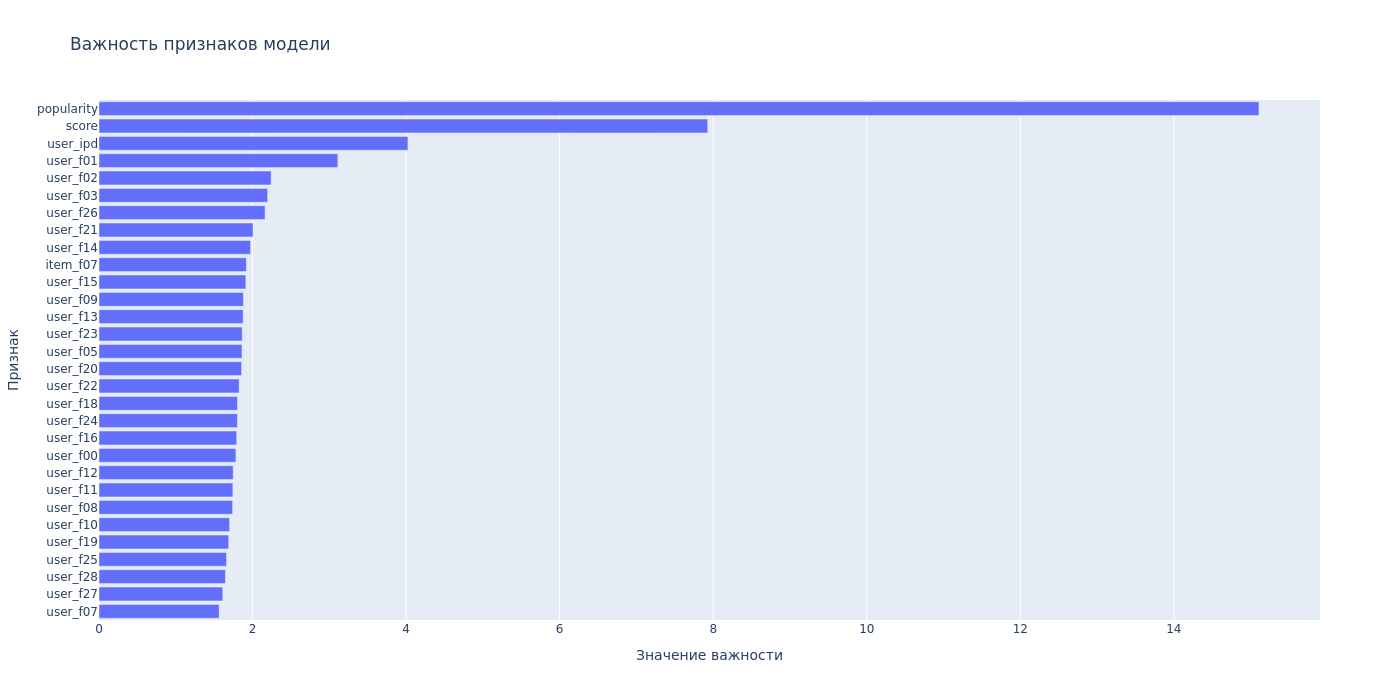

In [67]:
fig = pd.Series(
    cb_model.get_feature_importance(train_pool), index=cols
).sort_values(ascending=False).head(30).plot(
    kind="barh", title="Важность признаков модели",
    labels={"index": "Признак", "value": "Значение важности"}
)
fig.update_layout(
    height=700, width=1400, yaxis={"autorange": "reversed"},
    showlegend=False
)
fig.show(renderer="png")

Наиболее важным признаком модель определила популярность трека, от которого с большим отставанием расположился признак оценки трека моделью ALS. Далее также с большим отставанием располагаются признаки пользователей, а признаки трека имеют довольно низкую важность.

In [68]:
del train_pool, cb_model

### Рекомендации для ранжирования

Для получения финальных рекомендаций получим новые персональные рекомендации от ALS на базе всех событий горячих пользователей за исключением тестового датасета.

In [69]:
# Загрузка событий до разбиения данных
cols = ["user_id", "item_id", "item_seq"]
train = load_data(
    file_name="events.parquet", dir_name="data", 
    columns=cols, filters=[("started_at", "<", SPLIT_DATE)]
)

# Добавление событий из таргета
train = pd.concat([train, target[cols]], ignore_index=True)

del target
gc.collect()

train

,user_id,item_id,item_seq
0,0,99262,1
1,0,589498,2
2,0,590262,3
3,0,590303,4
4,0,590692,5
...,...,...,...
205765173,1374582,84543360,246
205765174,1374582,84657263,247
205765175,1374582,84823577,248
205765176,1374582,85347315,249


Оценим наличие `теплых` пользователей, у которых менее 5 прослушиваний.

In [70]:
train.groupby("user_id")["item_id"].count().loc[lambda x: x < 5]

user_id
92         4
315        3
594        1
637        1
758        3
          ..
1373683    2
1373932    2
1374011    3
1374071    3
1374520    1
Name: item_id, Length: 9982, dtype: int64

Сохраним идентификаторы `теплых` пользователей, они понадобятся для тестирования микросервиса. Для этого обучим новый энкодер идентификаторов.

In [ ]:
encoders["warm"] = LabelEncoder()
encoders["warm"].fit(
    train.groupby("user_id")["item_id"].count() \
        .loc[lambda x: x < 5] \
        .index.to_list()
)

Удалим таких пользователей из датасета.

In [71]:
train = train[train.groupby("user_id")["item_id"].transform("count") >= 5].copy()
train

,user_id,item_id,item_seq
0,0,99262,1
1,0,589498,2
2,0,590262,3
3,0,590303,4
4,0,590692,5
...,...,...,...
205765173,1374582,84543360,246
205765174,1374582,84657263,247
205765175,1374582,84823577,248
205765176,1374582,85347315,249


Обновим энкодеры для новой модели ALS.

In [72]:
for col in ["user", "item"]:
    encoders[col].fit(train[f"{col}_id"])

Подготовим разреженную матрицу для нового обучения модели ALS.

In [73]:
# Добавление весов
train["weight"] = asym_smoothing(
    train.groupby("user_id")["item_seq"].transform("max") - train["item_seq"])

# Преобразование user_id, item_id
for col in ["user", "item"]:
    train[f"{col}_id"] = encoders[col].transform(train[f"{col}_id"])

# Создание разреженной матрицы
train_sm = scipy.sparse.csr_matrix(
    (train["weight"], (train["user_id"], train["item_id"]))
)

del train

Обучим модель ALS на новых данных и сохраним модель после обучения.

In [ ]:
if os.path.exists("../models/als_model.pkl"):
    # Загрузка модели если она уже сохранена
    with open("../models/als_model.pkl", "rb") as fd:
        als_model = joblib.load(fd)
else:
    # Обучение модели на новых данных
    with threadpool_limits(1, "blas"):
        # Сброс факторов для нового обучения
        als_model.user_factors = None
        als_model.item_factors = None
        als_model.fit(train_sm, show_progress=False)
    # Сохранение обученной модели
    with open("../models/als_model.pkl", "wb") as fd:
        joblib.dump(als_model, fd)

Получим рекомендации для `горячих` пользователей, для ускорения возмьем только пользователей тестовой выборки. На каждого пользователя получим по 100 рекомендаций.

In [75]:
%%time

# Список горячих пользователей теста
test_users = pd.Series(encoders["user"].transform(list(
    set(encoders["user"].classes_) & 
    set(test["user_id"].unique())
))).sort_values()

personal_als = als_model.recommend(
    test_users, train_sm[test_users], 
    filter_already_liked_items=True, N=100)

del als_model, train_sm

CPU times: user 57min 55s, sys: 23min 10s, total: 1h 21min 6s
Wall time: 21min 5s


In [76]:
# Преобразование рекомендаций в табличный формат
item_ids_enc = personal_als[0] # type: ignore
als_scores = personal_als[1] # type: ignore

personal_als = pd.DataFrame({
    "user_id": test_users,
    "item_id": item_ids_enc.tolist(), 
    "score": als_scores.tolist()})

# Обратное кодирование id пользователей
personal_als["user_id"] = encoders["user"].inverse_transform(
    personal_als["user_id"])

# Преобразование списков 'item_id' и 'score' в строки
personal_als = personal_als.explode(["item_id", "score"], ignore_index=True)

# Приведение типов данных
personal_als["item_id"] = personal_als["item_id"].astype(np.int32)
personal_als["score"] = personal_als["score"].astype(np.float32)

# Обратное кодирование id треков
personal_als["item_id"] = encoders["item"].inverse_transform(
    personal_als["item_id"])

personal_als

,user_id,item_id,score
0,4,60292250,0.30
1,4,83100701,0.29
2,4,84010387,0.25
3,4,80614763,0.24
4,4,70408028,0.23
...,...,...,...
61536195,1374582,82206320,0.31
61536196,1374582,86324491,0.31
61536197,1374582,84215871,0.31
61536198,1374582,89273196,0.31


Сохраним персональные рекомендации в файле, а также сохраним энкодеры идентификаторов для возможности их дальнейшего использования.

In [ ]:
# Сохранение датасета
save_data(personal_als, "personal_als.parquet", "recommendations")

# Сохранение энкодеров 
with open("../models/id_encoders.pkl", "wb") as fd:
    joblib.dump(encoders, fd)

### Очистка памяти

Для выполнения дальнейшего кода необходимо очистить память путем перезапуска ядра Python.

In [78]:
# Остановка ядра для его перезапуска
exit()

### Ранжирование рекомендаций

В связи с ограничениями по оперативной памяти, что не позволяет получить полный датасет с признаками для модели, добавление признаков для модели ранжирования и ранжирование рекомендаций будет производиться батчами. Для этих целей подготовлена функция по добавлению признаков к персональным рекомендациям, полученным на предыдущем этапе.

> ⚠️ **ВАЖНО!!!** 
> Для выполнения последующего кода необходимо перезапустить ядро Python. После перезапуска необходимо выполнить все ячейки из раздела `Инициализация` для загрузки библиотек и констант, а также выполнить ячейку Этапа 3 раздела `Загрузка данных` для объявления функции загрузки.

In [7]:
# Загрузка датасетов
personal_als = load_data("personal_als.parquet", "recommendations")
item_pop = load_data("top_popular.parquet", "recommendations")
item_feats = load_data("item_feats.parquet", "features")
user_feats = load_data("hot_user_feats.parquet", "features")

In [ ]:
# Функция для получения датасета с признаками для ранжирующей модели

def add_features(
        df_als: pd.DataFrame,
        item_pop = item_pop,
        item_feats = item_feats,
        user_feats = user_feats
):
    """
    Функция для подготовки признаков для ранжирующей модели 
    путем добавления к персональным рекомендациям признаков 
    из сохраненных датасетов и удаления идентификаторов 
    пользователей и треков
    """
    # Работа с копией датасета
    df_als = df_als.copy()
    
    # Добавление популярности треков
    df_als = df_als.merge(
        item_pop, how="left", on="item_id")

    # Добавление признаков трека
    df_als = df_als.merge(
        item_feats,how="left", on="item_id")

    # Добавление признаков пользователя
    df_als = df_als.merge(
        user_feats, how="left", on="user_id")

    return df_als[df_als.columns[2:]]

# Переменная для сохранения ранжированных рекомендаций
final_recs = personal_als.copy()

# Проверка работы функции на батче из 1 тыс. записей
add_features(final_recs.iloc[:1000])

,score,popularity,item_f00,item_f01,item_f02,item_f03,item_f04,item_f05,item_f06,item_f07,...,user_f21,user_f22,user_f23,user_f24,user_f25,user_f26,user_f27,user_f28,user_f29,user_ipd
0,0.30,0.68,0.00,0.01,0.00,0.00,-0.00,0.00,0.00,0.00,...,0.00,0.02,0.04,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.93
1,0.29,0.14,0.02,0.25,1.28,-0.01,-0.00,-0.00,-0.00,0.00,...,0.00,0.02,0.04,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.93
2,0.25,0.14,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.02,0.04,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.93
3,0.24,0.07,1.19,-0.10,-0.00,-0.00,0.00,0.01,0.76,-0.00,...,0.00,0.02,0.04,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.93
4,0.23,0.15,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.02,0.04,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.26,0.08,1.25,-0.10,-0.00,-0.00,-0.00,-0.01,-0.66,0.00,...,-0.00,0.02,0.00,0.01,0.00,-0.00,-0.01,0.00,-0.00,5.37
996,0.26,0.20,1.25,-0.10,-0.00,-0.00,-0.00,-0.01,-0.66,0.00,...,-0.00,0.02,0.00,0.01,0.00,-0.00,-0.01,0.00,-0.00,5.37
997,0.25,0.02,1.19,-0.10,-0.00,-0.00,0.00,0.01,0.76,-0.00,...,-0.00,0.02,0.00,0.01,0.00,-0.00,-0.01,0.00,-0.00,5.37
998,0.25,0.10,0.00,0.01,-0.00,0.03,-0.00,0.00,0.00,1.00,...,-0.00,0.02,0.00,0.01,0.00,-0.00,-0.01,0.00,-0.00,5.37


Ранжируем полученные рекомендации.

In [ ]:
%%time

# Инициализация переменных/констант
BATCH_SIZE = 25_000_000
cb_model = CatBoostClassifier()
cb_model.load_model("../models/model.cb")
ranks = []

# Обработка батчей
for start in range(0, final_recs.shape[0], BATCH_SIZE):
    end = start + BATCH_SIZE
    ranks.extend(cb_model.predict_proba(
        add_features(final_recs.iloc[start:end]))[:, 1])

final_recs["score"] = ranks
final_recs

CPU times: user 25min 32s, sys: 19.2 s, total: 25min 52s
Wall time: 7min 9s


,user_id,item_id,score
0,4,60292250,1.00
1,4,83100701,0.21
2,4,84010387,0.97
3,4,80614763,0.72
4,4,70408028,0.03
...,...,...,...
61536195,1374582,82206320,0.15
61536196,1374582,86324491,0.63
61536197,1374582,84215871,0.47
61536198,1374582,89273196,0.53


Сохраним ранжированные рекомендации в файл `recommendations.parquet` директории `recommendations` в порядке убывания ранга для каждого пользователя.

In [10]:
final_recs.sort_values(by=["user_id", "score"], inplace=True)

save_data(final_recs, "recommendations.parquet", "recommendations")

## Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

Для начала оценим распределение событий `горячих` пользователей тестовой выборки.

In [ ]:
# Загрузка энкодера идентификаторов
with open("../models/id_encoders.pkl", "rb") as fd:
    encoders = joblib.load(fd)

_, test = split_target_test(
    load_data(
        "events.parquet", "data",
        filters=[("started_at", ">=", SPLIT_DATE)]),
    encoders["user"].classes_
)

del _

print("Распределение событий 'горячих' пользователей:")
test[test["user_id"].isin(encoders["user"].classes_)] \
    .groupby("user_id")["item_id"].count() \
    .describe(PERCENTILES).to_frame().T

Распределение событий 'горячих' пользователей:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
item_id,613302.00,9.65,14.10,1.00,1.00,1.00,1.00,4.00,11.00,43.00,67.00,94.00


Распределение событий тестовой выборки по пользователям сдвинуто к меньшему количеству прослушиваний - не менее 5% таких пользователей имеют только одно прослушивание, а 50% пользователей прослушало менее 5 треков. Причиной этого послужил способ разделения отложенной выборки на датасеты с таргетом и новую тестовую выборку, таким образом в таргеты перенесено более половины треков горячих пользователей и все пользователи с одним прослушиванием. Оценим какое распределение по `теплым` и `холодным` пользователям.

In [ ]:
print("Распределение событий остальных пользователей:")
test[~test["user_id"].isin(encoders["user"].classes_)] \
    .groupby("user_id")["item_id"].count() \
    .describe(PERCENTILES).to_frame().T

Распределение событий остальных пользователей:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
item_id,38928.00,31.26,26.53,1.00,1.00,5.00,13.00,22.00,41.00,90.00,122.00,151.00


Заметен сильный сдвиг вправо к большему количеству событий для новых пользователей, большинство из них показывают довольно высокую активность - более 50% таких пользователей прослушало не меньше 22 треков.

Исходя из количества треков определим K=10 для метрик оценки качества, при котором метрика Racall@K будет репрезентативной для довольно большой части датасета и обеспечит относительно хороший баланс между полнотой и точностью.

Подготовим функцию для рассчета метрик.

In [ ]:
# Определение K
K = 10

# Загрузка всех событий пользователей
user_events = test["user_id"].unique()
user_events = load_data(
    "events.parquet", "data",
    columns=["user_id", "item_id"],
    filters=[("user_id", "in", user_events)]
)

# Функция для рассчета метрик
def eval_recs(
        recs_df: pd.DataFrame, 
        events_df=user_events,
        test_df=test[["user_id", "item_id"]],
        item_count=item_pop.shape[0],
        K=K
) -> dict:
    """
    Функция для получения метрик Precision@K, Recall@K, Coverage@K и Novelty@K

    Parameters
    ----------
    recs_df : DataFrame
        Датафрейм с рекомендациями, колонки `user_id`, `item_id`, `score`
    events_df : DataFrame
        Список всех событий пользователей для рассчета Novelty@K, 
        колонки `user_id`, `item_id` 
    test_df : DataFrame
        Список тестовых событий пользователей, колонки `user_id`, `item_id`
    item_count : int
        Общее количество item для рассчета Coverage@K
    K : int
        Количество рекомендаций для отбора по `score`

    Returns
    -------
    metrics : dict
        Возвращает метрики в виде словаря
    """

    if not (isinstance(item_count, int) and (item_count > 0)):
        raise ValueError("item_count must be int > 0")
    if not (isinstance(K, int) and (K > 0)):
        raise ValueError("'K' must be int > 0")
    
    # Получение словаря пользователей со списком K рекомендаций
    recs_df = recs_df.sort_values(by=["user_id", "score"], ascending=[True, False]) \
        .groupby("user_id")["item_id"].agg(lambda x: x.iloc[:K].to_list()).to_dict()
    # Получение словарей пользователей со множеством прослушанных треков
    test_df = test_df.groupby("user_id")["item_id"].agg(set).to_dict()
    events_df = events_df.groupby("user_id")["item_id"].agg(set) \
        .to_dict()

    precision = []
    recall = []
    coverage = set()
    novelty = []

    # Перебор пользователей датасета
    for user, rec_items in recs_df.items():
        # Получение прослушанных треков
        rel_items = test_df.get(user, set())
        # Количество совпадений треков
        hits = len(set(rec_items) & rel_items)
        # Незнакомые треки как разница множества рекомендаций 
        # и прослушанных треков без треков из тестовой выборки
        unknown_items = set(rec_items).difference(
            events_df.get(user, set()).difference(rel_items))

        # Precision@K
        precision.append(hits / K)

        # Recall@K
        recall.append(
            hits / len(rel_items) 
                if len(rel_items) > 0 else 0)
        
        # Список для Coverage@K
        coverage.update(rec_items)

        # Novelty@K
        novelty.append(len(unknown_items) / len(rec_items))

    return {
        "Precision@K": np.mean(precision),
        "Recall@K": np.mean(recall),
        "Coverage@K": len(coverage) / item_count,
        "Novelty@K": np.mean(novelty)
    }

### Топ популярных

Рассчитаем рекомендации как топ K популярных для новых пользователей тестовой выборки, которые не являются `горячими` пользователями.

In [ ]:
# Загрузка энкодеров id для получения 
# списка горячих пользователей
with open("../models/id_encoders.pkl", "rb") as fd:
    encoders = joblib.load(fd)

# Список новых пользователей
top_popular = list(
    set(test["user_id"].unique()) - 
    set(encoders["user"].classes_)
)

# Получение ТОП K популярных как рекомендации 
# для новых пользователей тестовой выборки
top_popular = pd.DataFrame(
    {"user_id": top_popular}
).merge(item_pop.head(K), how="cross") \
    .rename(columns={"popularity": "score"})
top_popular

,user_id,item_id,score
0,1179649,53404,1.00
1,1179649,33311009,0.92
2,1179649,178529,0.92
3,1179649,35505245,0.87
4,1179649,24692821,0.77
...,...,...,...
389275,786431,795836,0.76
389276,786431,6705392,0.73
389277,786431,32947997,0.73
389278,786431,37384,0.72


Рассчитаем метрики для таких рекомендаций.

In [ ]:
metrics = pd.DataFrame()
metrics["Top popular (new)"] = pd.Series(
    eval_recs(top_popular))
metrics.T

,Precision@K,Recall@K,Coverage@K,Novelty@K
Top popular (new),0.03,0.01,0.00,1.00


Метрики довольно низкие, кроме Novelty@K, явно ТОП самых популярных треков не так часто прослушивался новыми пользователями. Для сравнения рассчитаем метрики ТОП популярных треков для всех пользователей тестового датасета.

In [ ]:
# Расчет метрик для ТОП K популярных треков 
# для всех пользователей тестовой выборки
metrics["Top popular (all)"] = eval_recs(pd.DataFrame(
    {"user_id": test["user_id"].unique()}
).merge(item_pop.head(K), how="cross") \
    .rename(columns={"popularity": "score"}))
metrics.T

,Precision@K,Recall@K,Coverage@K,Novelty@K
Top popular (new),0.03,0.01,0.00,1.00
Top popular (all),0.00,0.00,0.00,0.93


На полном датасете метрики еще ниже, также немного снизилась метрика Novelty@K, так как некоторые пользователи прослушивали треки из ТОП K по популярности.

### Персональные ALS

In [ ]:
metrics["Personal ALS (hot)"] = pd.Series(
    eval_recs(personal_als))
metrics.T

,Precision@K,Recall@K,Coverage@K,Novelty@K
Top popular (new),0.03,0.01,0.00,1.00
Top popular (all),0.00,0.00,0.00,0.93
Personal ALS (hot),0.02,0.03,0.00,1.00


Метрика Precision@K немного ниже, при этом более высокое значение Recall@K - это говорит о том, что рекомендательная система находит больше релевантных объектов, хотя точность снизилась. Это говорит о том, что из K рекомендаций меньше релевантных значений, что не удивительно, так как для большей части пользователей мало совпадений по причине довольно малого числа прослушиваний новых треков. Из 10 рекомендаций мало пользователей в принципе прослушало сравнимое число треков. Ну и очевидно, что ALS рекомендует только не прослушанные ранее треки, поэтому метрика Novelty@K высокая.

Оценим метрики на всем датасете, где для новых пользователей оставим ТОП популярных как рекомендации.

In [ ]:
metrics["Perosnal ALS (all)"] = pd.Series(
    eval_recs(pd.concat(
        [personal_als, top_popular], ignore_index=True)))
metrics.T

,Precision@K,Recall@K,Coverage@K,Novelty@K
Top popular (new),0.03,0.01,0.00,1.00
Top popular (all),0.00,0.00,0.00,0.93
Personal ALS (hot),0.02,0.03,0.00,1.00
Perosnal ALS (all),0.02,0.03,0.00,1.00


Для полного датасета метрики изменились незначительно, так как горячих пользователей существенно больше, чем новых.

### Итоговые рекомендации

Оценим метрики по результатам ранжирования рекомедаций.

In [ ]:
metrics["Final recs (hot)"] = pd.Series(eval_recs(final_recs))
metrics.T

,Precision@K,Recall@K,Coverage@K,Novelty@K
Top popular (new),0.03,0.01,0.00,1.00
Top popular (all),0.00,0.00,0.00,0.93
Personal ALS (hot),0.02,0.03,0.00,1.00
Perosnal ALS (all),0.02,0.03,0.00,1.00
Final recs (hot),0.03,0.04,0.01,1.00


По метрикам можно отметить рост Precision@K и Recall@K, что говорит как увеличении как полноты, так и точности рекоммендаций. Также с применением финальных рекомендаций заметен рост метрики Coverage@K, что говорит о большем разнообразии таких рекомендаций. Получим метрики для всех пользователей с учетом новых с рекомендациями ТОП K самых популярных.

In [ ]:
metrics["Final recs (all)"] = pd.Series(eval_recs(
    pd.concat([
        final_recs, top_popular],
        ignore_index=True)))
metrics.T

,Precision@K,Recall@K,Coverage@K,Novelty@K
Top popular (new),0.03,0.01,0.00,1.00
Top popular (all),0.00,0.00,0.00,0.93
Personal ALS (hot),0.02,0.03,0.00,1.00
Perosnal ALS (all),0.02,0.03,0.00,1.00
Final recs (hot),0.03,0.04,0.01,1.00
Final recs (all),0.03,0.04,0.01,1.00


Метрики изменились незначительно, так как новых пользователей существенно меньше, чем горячих.

# === Выводы, метрики ===

В рамках настоящего проекта подготовлен MVP рекомендательной системы музыкального сервиса. 
1. На первом этапе произведена оценка выгруженных данных по взаимодействиям пользователей с новыми треками за 2022 год. В рамках произведенной оценки можно выделить следующее:
    - имеются пропуски в альбомах, артистах и жанрах треков, стоит оценить корректность таких фактов;
    - в датасете с каталожными наименованиями имеются расхождения в жанрах - часть жанров не представлена, а также имеются жанры, которые отсутствуют в датасете со взаимодействиями, взможно допущена ошибка при выгрузке;
    - имеются пользователи с аномально большим количеством взаимодействий по сравнению с основной массой пользователей.
    
    По результатам первого этапа были исключены 90% самых первых взаимодействий у пользователей с аномально большим их количеством. Все пропуски заполнены значениями 'unknown', а по жанрам - 96 'other' (можно заполнить и значением 0 'all').

2. Вторым этапом произведен исследовательский анализ данных EDA, а также сохранен датасет после очистки. Каких-то существенных аномалий не выявлено, однако заметно значительное снижение количества новых прослушиваний в декабре 2022 года, что повлияло на разделение отложенного тестового датасета.

3. В рамках третьего этапа на основании тренировочной выборки получены данные по популярности треков, а также посредством модели ALS подготовлены датасеты с персональными рекомендациями для горячих пользователей и похожими треками для возможности дальнейшего применения для онлайн рекомендаций. 

    При подготовке матрицы взаимодействий для модели ALS подготовлена функция для рассчета весов таких взаимодействий на основании порядка их прослушивания - самые последние треки получают больший вес по сравнению с давно прослушанными треками. Эта функция также позволяет оставить высокие веса для пользователей с малым количеством взаимодействий и существенно снизить веса для не самых последних треков у пользователей с большим количеством взаимодействий.

    На базе полученных персональных рекомендаций, в соответствии с двухстадиным подходом подготовлена модель для ранжирования рекомендаций на базе модели CatBoost. В качестве признаков для модели ранжирования выбраны следующие:
    - полученные от ASL веса для рекомендаций;
    - популярность трека в тренировочной выборке со значениями от 0 до 1 для самого популярного;
    - эмбеддинги трека по жанрам посредством Truncated SVD;
    - эмбеддинги пользователя по жанрам посредством Truncated SVD;
    - среднее количество новых прослушиваний треков в день для пользователя.

    Для получения целевых треков модели ранжирования произведено разделение отложенной тестовой выборки на датасет для целевых треков (таргетов) и новой тестовой выборки. Так как на конец декабря 2022 года приходилось сильное снижение по количеству новых прослушиваний треков, было решено разделение производить не по дате, а по количеству прослушиваний на пользователя. Пользователи, прослушавшие меньше 2 треков, а также бо́льшая часть треков с нечетным количеством прослушиваний `горячими` пользователями попали в датасет для целевых треков. Вторая половина треков, а также новые и `теплые` пользователи попали в новую тестовую выборку. В результате чего получилось подготовить датасет с кандидатами на обучение модели, в который попали более 42.5% от всех `горячих` пользователей.

    Произведено обучение модели на подготовленных кандидатах и ранжирование новых рекомендаций, полученных моделью ALS с учетом новых взаимодействий (таргетов). Произведена оценка следующих типов рекомендаций:
    - топ популярных,
    - персональных ALS,
    - итоговых

    по четырем метрикам: recall, precision, coverage, novelty.

4. Результаты оценки рекомендаций:
    - Топ популярных:
    Precision@10:    0.03;
    Recall@10:       0.01;
    Coverage@10:     0.00;
    Novelty@10:      1.00;

    - Персональных:
    Precision@10:    0.02;
    Recall@10:       0.03;
    Coverage@10:     0.00;
    Novelty@10:      1.00;

    - Итоговых:
    Precision@10:    0.03;
    Recall@10:       0.04;
    Coverage@10:     0.01;
    Novelty@10:      1.00;

    Метрики на тестовой выборке достаточно низкие, причиной этому можно отметить сильный дисбаланс по количеству прослушиваний - большая часть пользователей имеет низкое количество новых прослушиваний. Однако применение двухстадийного подхода позволило улучшить метрики.

5. Рекомендации по дальнейшему улучшению MVP рекомендательной системы:
    - рассмотреть возможность сегментации пользователей по количеству прослушиваний и подготовку рекомендаций для таких сегментов разными моделями;
    - дополнить сведениями о количестве прослушиваний каждого трека, для подбора оптимального веса модели ALS для новых треков, так как они могут быть не совсем актуальными - случайное разовое прослушивание не интересного для пользователя трека;
    - дополнить ранжирующую модель дополнительными признаками пользователей, такими как пол, возраст и т.п.;
    - для генерации эмбеддингов треков использовать не только жанры, а также альбомы и исполнителей и других метаданных треков;
    - рассмотреть другие способы генерации эмбеддингов для пользователей и треков, например AutoEncoder, графовые методы или трансформеры;
    - глубокий fine-tuning моделей.